In [1]:

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import fitsio
import numpy as np
import pyarrow.parquet as pq
import pyarrow as pa
import scienceplots
plt.style.use(['science','notebook','grid'])
import glob
import os
from astropy.table import Table

In [2]:
files= glob.glob('/user/animesh.sah/w_theta_results/*')
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())

from scipy.stats import gaussian_kde
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(700).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

#plt.hist(matched_dr['Z'],bins=30,edgecolor='blue',label='DESI Spectral',density=True)

#plt.plot(samples_sorted,y_samples_sorted,'.',alpha=0.6)
z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
dL = cosmo.comoving_distance(samples_sorted).to(u.Mpc).value
num  = np.trapz(dL*n_z**2, z)
denom  = np.trapz(n_z**2, z)
chi_eff = num/denom
def theta_to_r(theta_deg):
    return chi_eff * np.deg2rad(theta_deg)

def r_to_theta(r_mpc):
    return np.rad2deg(r_mpc / chi_eff)


In [3]:
zeff = np.trapz(z*n_z, z) /np.trapz(n_z, z)
print('zeff = ', zeff)
dc_zeff= cosmo.comoving_distance(zeff).to(u.Mpc).value
dc_zeff

def theta_to_r_dc(theta_deg):
    return dc_zeff * np.deg2rad(theta_deg)
def r_to_theta_dc(r_mpc):
    return np.rad2deg(r_mpc / dc_zeff)

zeff =  0.09167795234288294


In [4]:
#files

files_point = np.sort([file for file in files if  'jackknife'  not in file and 'bootstrap' not in file and  '0.001_to_100' in file ])
files_point

array(['/user/animesh.sah/w_theta_results/corrfunc_full_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_full_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_north_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_north_none_patches_100_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_south_0.001_to_100.npy'],
      dtype='<U82')

In [5]:
files_point

array(['/user/animesh.sah/w_theta_results/corrfunc_full_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_full_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_north_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_north_none_patches_100_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_south_0.001_to_100.npy'],
      dtype='<U82')

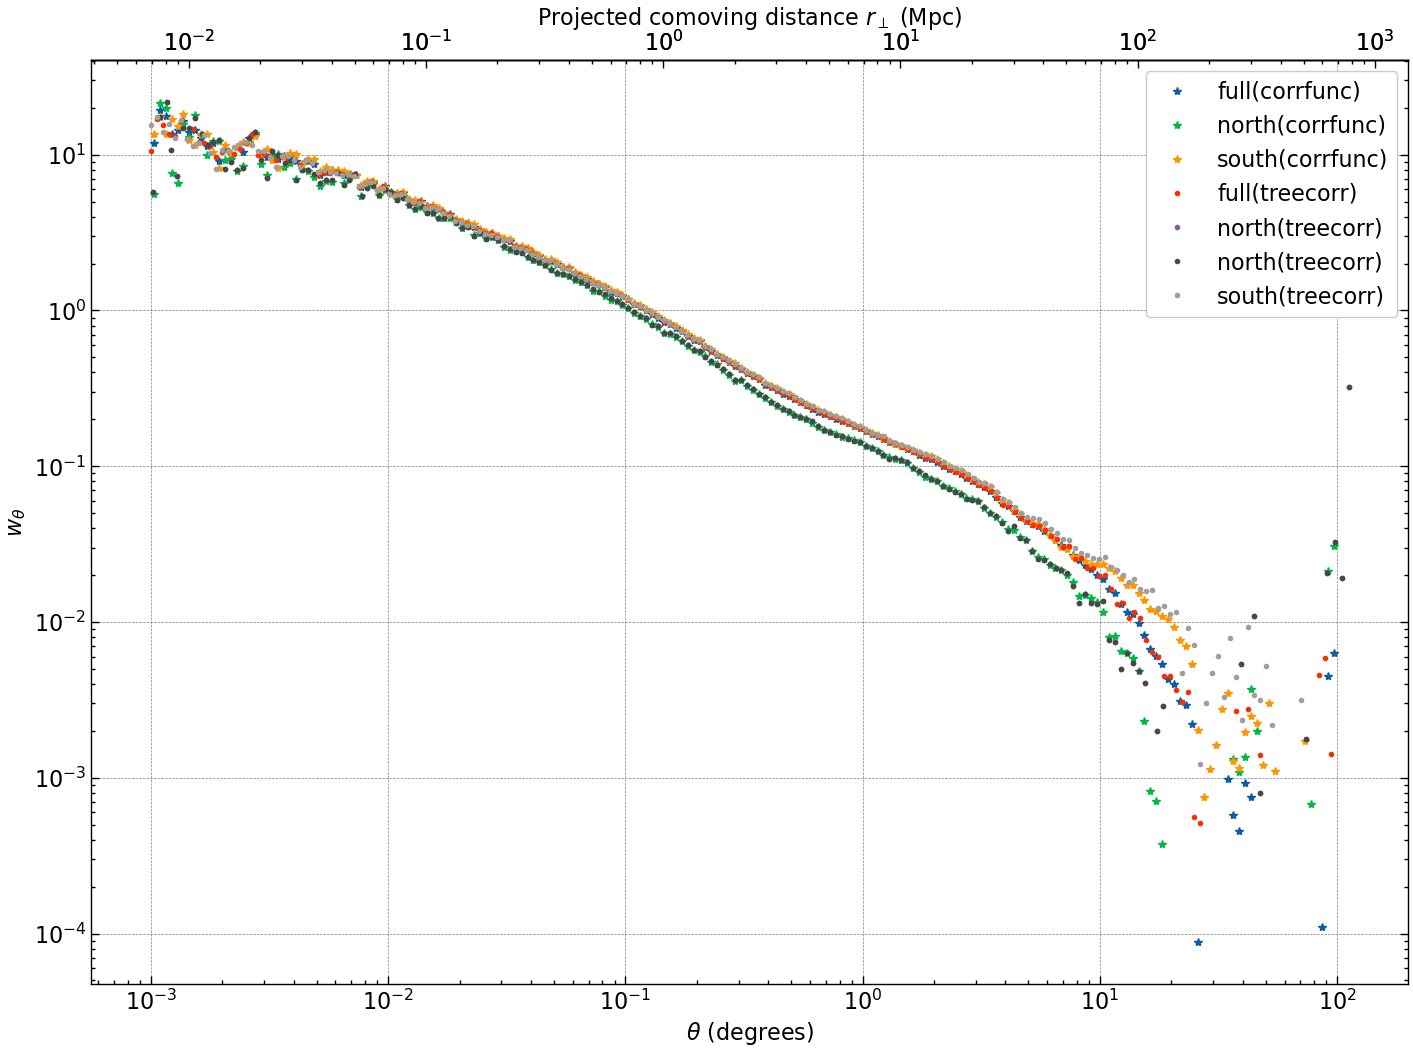

In [6]:
color = ['k','r','b','g']
fig,ax = plt.subplots(figsize=(17,12))
for file in files_point: 
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    if  'corrfunc' in name:
        ax.plot(dat[0],dat[1],label=name,marker='*',linestyle='None')
    else: 
        ax.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
    #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')

plt.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()

In [ ]:
# files= glob.glob('/user/animesh.sah/w_theta_results/*')

# plt.figure(figsize=(15,10))
# files = [file for file in files if '100' in file]
# color = ['k','r','b','g']
# for file in files: 

#     dat = np.load(file)
#     name = os.path.basename(file)
#     name = name.replace('.npy','')
#     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
#     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     plt.xscale('log')
#     plt.yscale('log')
# plt.legend()

In [7]:
# files= glob.glob('/user/animesh.sah/w_theta_results/*')

# files = [file for file in files if '100' in file]


# part = ['north','south','full']


# {patch: [file for file in files if patch in file] for patch in part}


# for patch in part:
#     plt.figure(figsize=(15,10))

#     files_sub = [file for file in files if patch in file]
#     ar = []
#     for file in files_sub:
#         dat = np.load(file)
#         name = os.path.basename(file)
#         name = name.replace('.npy','')
#         name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
#         ar.append(dat[1])
#         #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     plt.plot(dat[0],100*(ar[0]-ar[1])/ar[0],'.')
#     plt.ylabel(r'$(w_{\theta, treecorr} - w_{\theta, corrfunc})/w_{\theta, treecorr} \times 100$')
#     plt.xscale('log')
#     plt.yscale('symlog', linthresh=0.1)

#     plt.title(patch)
#     plt.legend()
#     plt.show()


# # for file in files: 
# #     dat = np.load(file)
# #     name = os.path.basename(file)
# #     name = name.replace('.npy','')
# #     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'

# #   if 'north' in name:
# #         ar1 = 

        
# #     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
# #     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
# #     plt.xscale('log')
# #     plt.yscale('log')
# # plt.legend()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


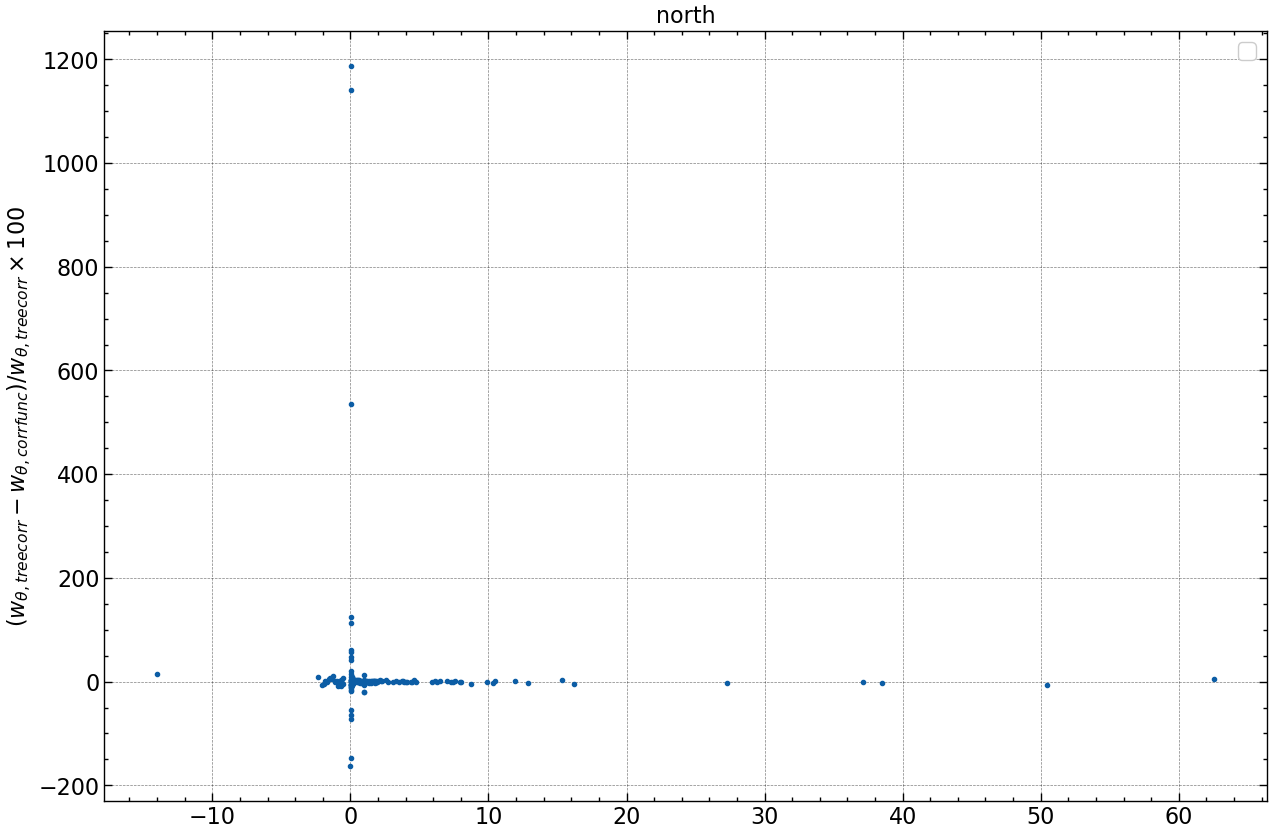

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


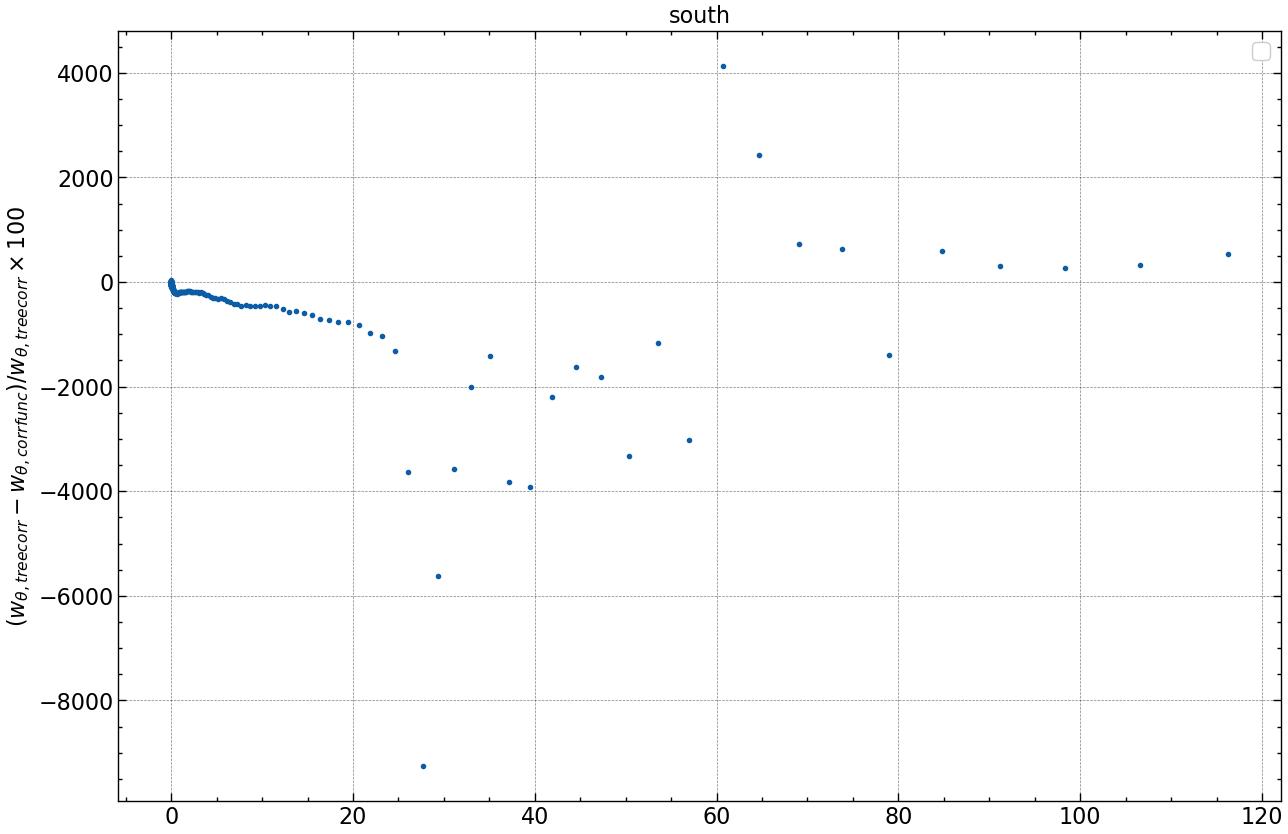

ValueError: x and y must have same first dimension, but have shapes (200,) and (2, 200)

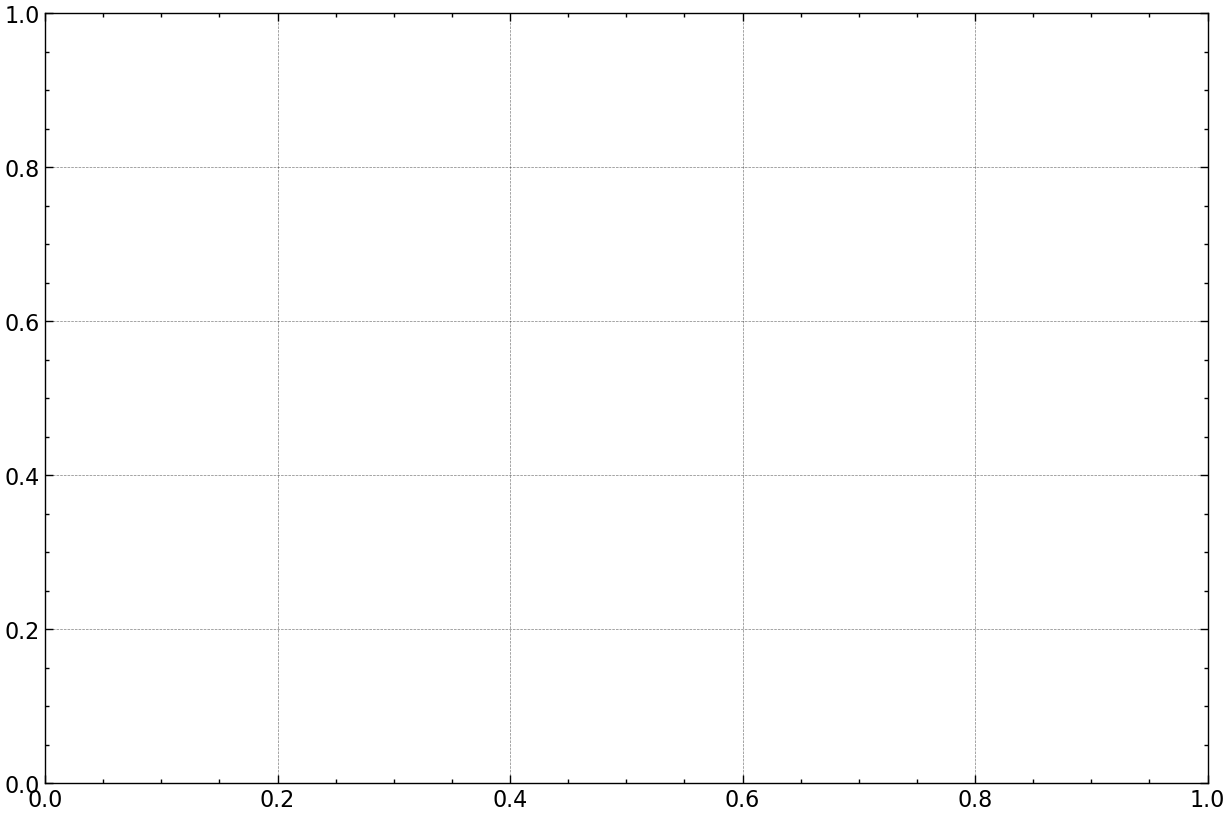

In [8]:
files= glob.glob('/user/animesh.sah/w_theta_results/*')

files = [file for file in files if '100' in file]


part = ['north','south','full']


{patch: [file for file in files if patch in file] for patch in part}


for patch in part:
    plt.figure(figsize=(15,10))

    files_sub = [file for file in files if patch in file]
    ar = []
    for file in files_sub:
        dat = np.load(file)
        name = os.path.basename(file)
        name = name.replace('.npy','')
        name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
        ar.append(dat[1])
        #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
    plt.plot(dat[0],100*(ar[0]-ar[1])/ar[0],'.')
    plt.ylabel(r'$(w_{\theta, treecorr} - w_{\theta, corrfunc})/w_{\theta, treecorr} \times 100$')
    # plt.xscale('log')
    # plt.yscale('symlog', linthresh=0.1)

    plt.title(patch)
    plt.legend()
    plt.show()


# for file in files: 
#     dat = np.load(file)
#     name = os.path.basename(file)
#     name = name.replace('.npy','')
#     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'

#   if 'north' in name:
#         ar1 = 

        
#     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     plt.xscale('log')
#     plt.yscale('log')
# plt.legend()


In [ ]:
files_jackknife

NameError: name 'files_jackknife' is not defined

NameError: name 'theta_deg' is not defined

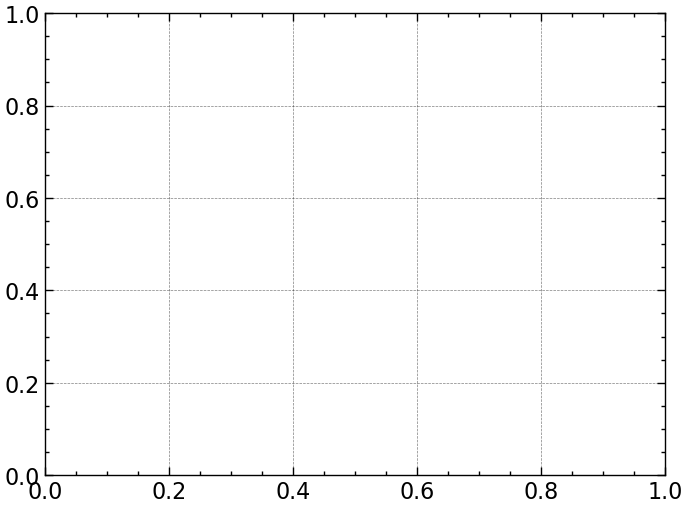

In [ ]:
fig, ax = plt.subplots()
ax.loglog(theta_deg, omega_theta, marker='o')
ax.set_xlabel(r'$\theta$ (deg)')
ax.set_ylabel(r'$w(\theta)$')

# add distance top axis
secax = ax.secondary_xaxis('top',
    functions=(theta_to_r, r_to_theta))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')


In [ ]:
files_jackknife_200[0]
files_bootstrap[0]

jk= np.load(files_jackknife_200[0])
b = np.load(files_bootstrap[0])
fig, ax = plt.subplots(figsize=(15,10))
ax.errorbar(b[0][::2],b[1][::2],yerr=b[2][::2],label='bootstrap',marker='*',linestyle='None',capsize=3,alpha=0.8)
ax.errorbar(jk[0][::2],jk[1][::2],yerr=jk[2][::2],label='jackknife',marker='o',linestyle='None',capsize=3,alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
ax.set_yscale('log')
plt.legend()


NameError: name 'files_jackknife_200' is not defined

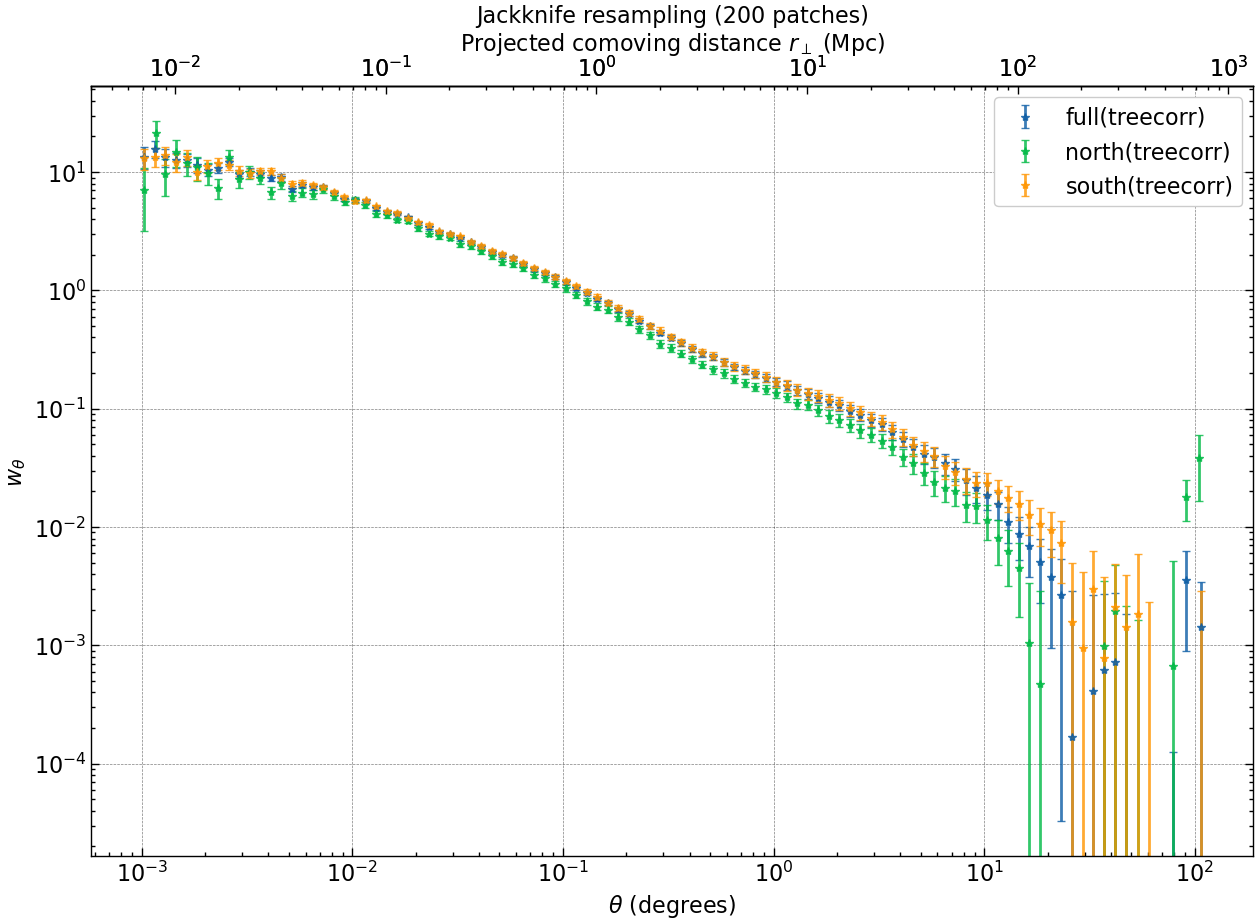

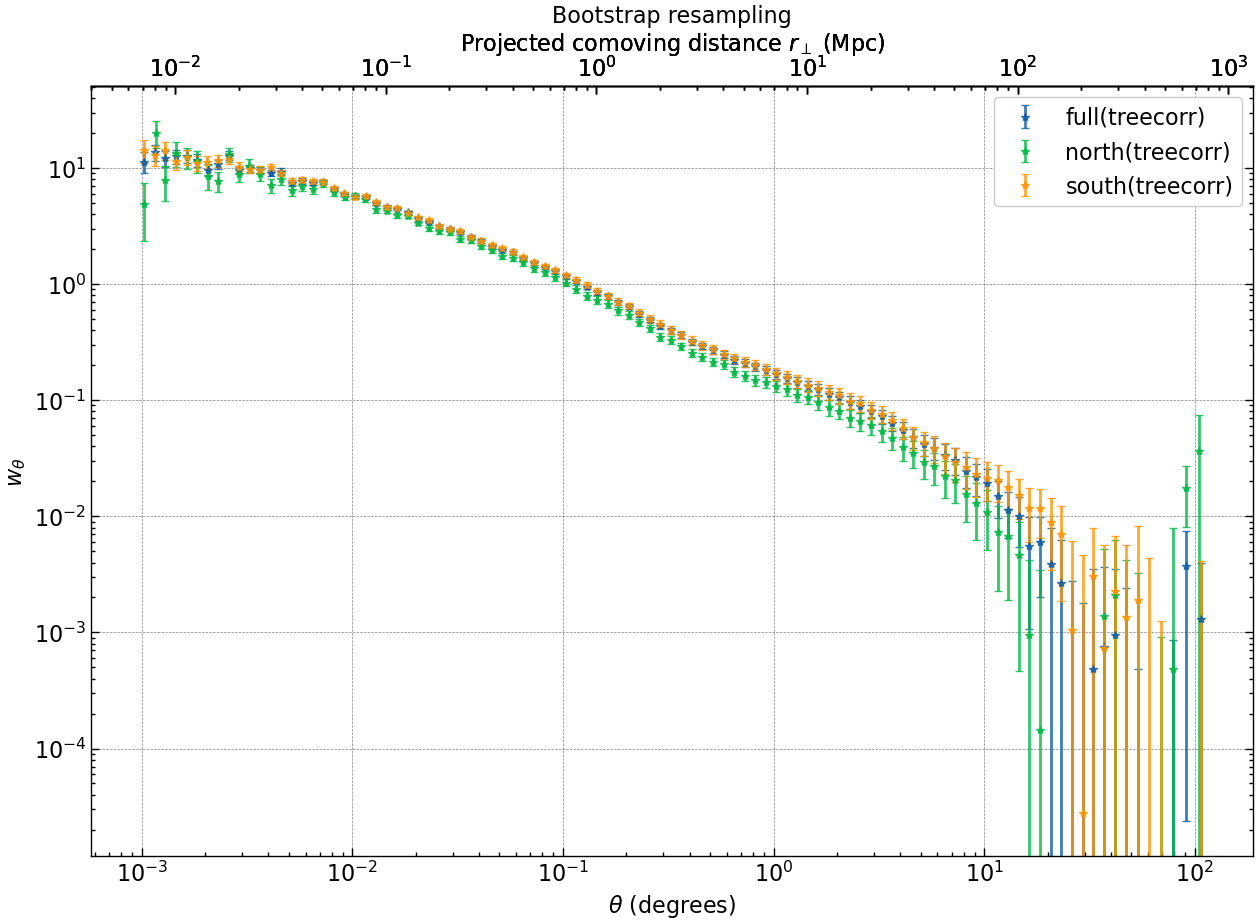

In [36]:
files= glob.glob('/user/animesh.sah/w_theta_results/*')

files_jackknife_200 = np.sort([file for file in files if  'jackknife'  in file and '200' in file])

files_bootstrap = np.sort([file for file in files if  'bootstrap'  in file and 'treecorr' in file])
#part = ['north','south','full']


#{patch: [file for file in files if patch in file] for patch in part}

#plt.figure(figsize=(15,10))
fig, ax = plt.subplots(figsize=(15,10))

for file in files_jackknife_200:
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    ax.set_title('Jackknife resampling (200 patches)')
    ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()


fig, ax = plt.subplots(figsize=(15,10))

for file in files_bootstrap:
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    ax.set_title('Bootstrap resampling')
    ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\theta$ (degrees)')
    ax.set_ylabel(r'$w_{\theta}$')
    secax = ax.secondary_xaxis('top',
    functions=(theta_to_r_dc,r_to_theta_dc))
    secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

plt.legend()


# for file in files: 
#     dat = np.load(file)
#     name = os.path.basename(file)
#     name = name.replace('.npy','')
#     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'

#   if 'north' in name:
#         ar1 = 

        
#     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     plt.xscale('log')
#     plt.yscale('log')
# plt.legend()


In [35]:
files_bootstrap

array(['/user/animesh.sah/w_theta_results/corrfunc_full_bootstrap__num_bootstrap_10_0.001_to_10_v2.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap__num_bootstrap_10000_0.001_to_10_v2.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap__num_bootstrap_100_0.001_to_10_v2.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap__num_bootstrap_2000_0.001_to_10_v2.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_0.1_test.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by1.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by10.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by2.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by5.npy',
       '/use

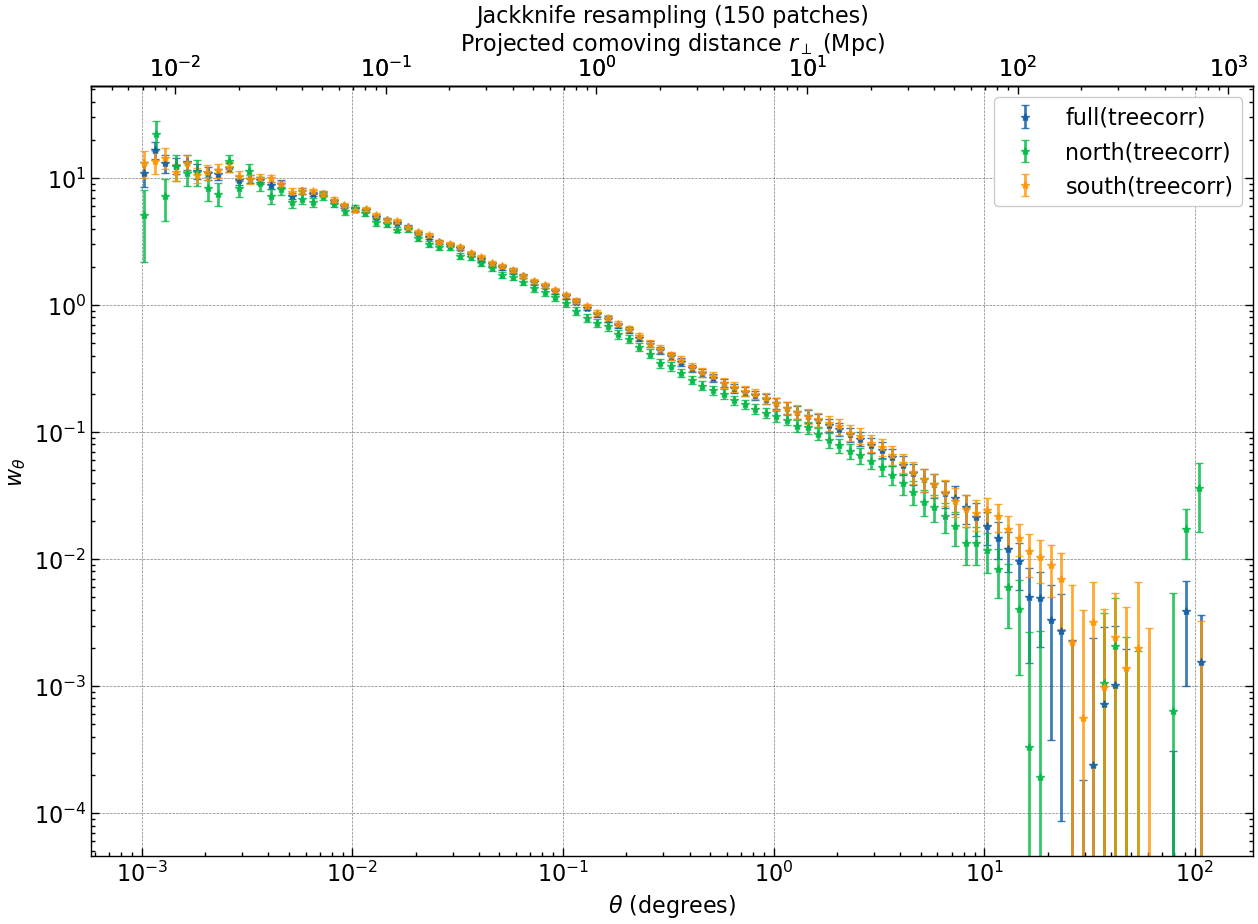

In [10]:

files_jackknife_150 = [file for file in files if  'jackknife'  in file and '150' in file]



#{patch: [file for file in files if patch in file] for patch in part}

fig, ax = plt.subplots(figsize=(15,10))
for file in files_jackknife_150:
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    ax.set_title('Jackknife resampling (150 patches)')
    ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{\theta}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()

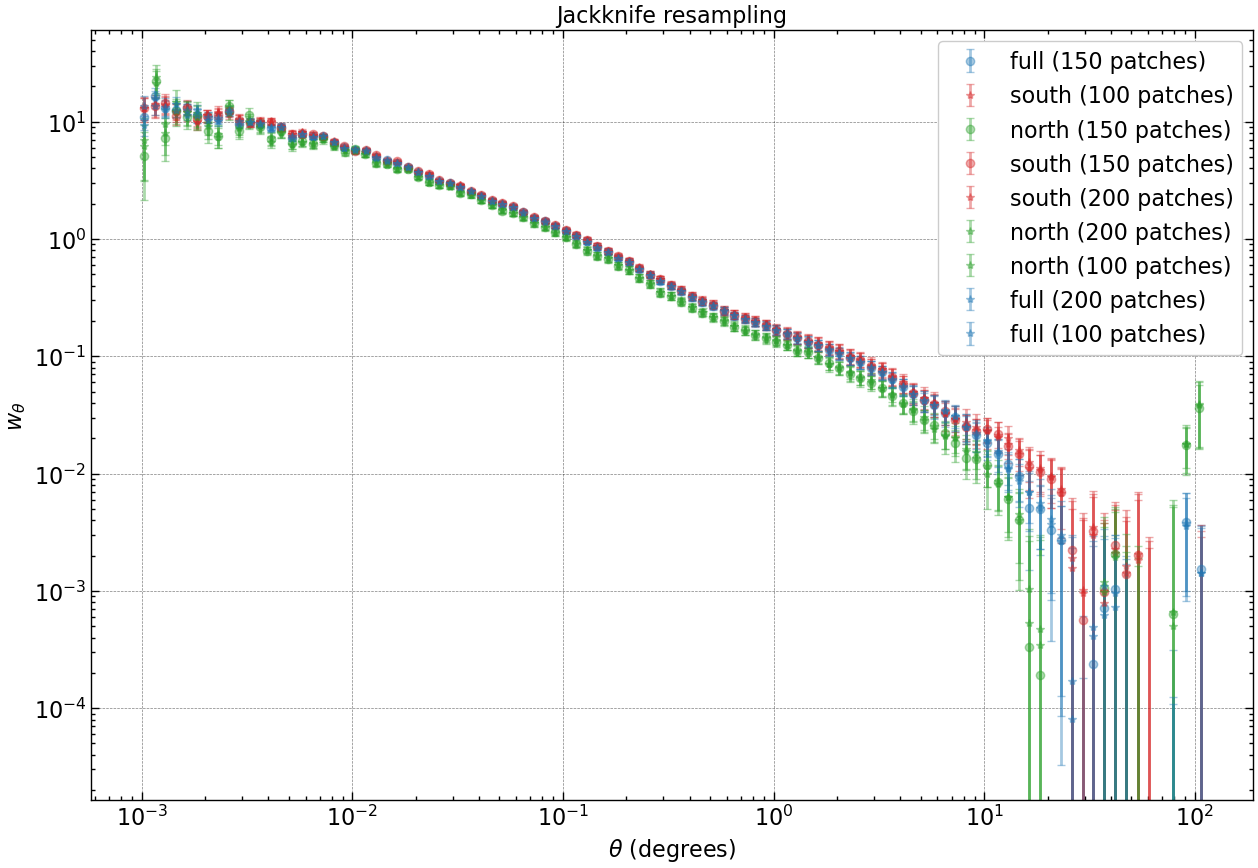

In [11]:
files_jackknife = [file for file in files if  'jackknife'  in file and 'treecorr' in file]

plt.figure(figsize=(15,10))

region_colors = {
    "north": "tab:green",
    "south": "tab:red",
    "full":  "tab:blue"
}
patch_styles = {
    "150": {"marker": "o"},
    "200": {"marker": "*"}
}
for file in files_jackknife:
    dat = np.load(file)
    name = os.path.basename(file).replace(".npy", "")

    # parse region and patch number from filename
    parts = name.split("_")
    region = parts[1]   # full, south, north
    patchnum = parts[4] # 150 or 200

    color = region_colors.get(region, "black")
    style = patch_styles.get(patchnum, {"marker": "*", "linestyle": "None"})

    label = f"{region} ({patchnum} patches)"
    try:
        plt.errorbar(
            dat[0][::2], dat[1][::2], yerr=dat[2][::2],
            label=label,
            color=color,
            marker=style["marker"],
            linestyle='None',
            capsize=3,
            alpha=0.4
        )
    except Exception as e:
        print(f"Error plotting {name}: {e}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\theta$ (degrees)")
plt.ylabel(r"$w_{\theta}$")
plt.title("Jackknife resampling")
plt.legend()
plt.show()

In [12]:
np.log10(r_to_theta_dc(40)) , np.log10(20)

(0.7615508854903494, 1.3010299956639813)

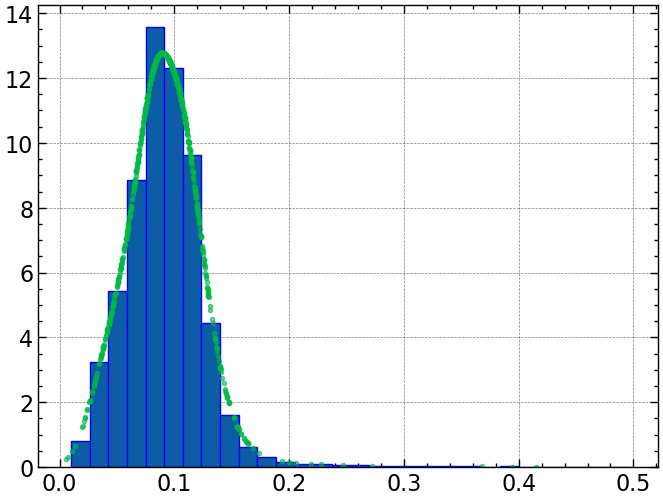

In [49]:
import pyccl as ccl

cosmo = ccl.Cosmology(
    Omega_c=0.25,  # Cold dark matter density
    Omega_b=0.05,  # Baryon density
    h=0.67,        # Hubble parameter
    sigma8=0.8,    # Power spectrum normalization
    n_s=0.96       # Spectral index
, matter_power_spectrum='halofit',
transfer_function='boltzmann_camb',
extra_parameters={"camb":{"halofit_version": "mead2020_feedback","HMCode_logT_AGN":7.75}})
import numpy as np
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())

from scipy.stats import gaussian_kde
kde = gaussian_kde(matched_dr['Z'],bw_method=0.28)
samples = kde.resample(700).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

plt.hist(matched_dr['Z'],bins=30,edgecolor='blue',label='DESI Spectral',density=True)

plt.plot(samples_sorted,y_samples_sorted,'.',alpha=0.6)
z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)

In [50]:
gal_tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
cl = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
theta = np.logspace(0.75, 1.2, 50)  # in radians (~0.06° to 57°)
wtheta = ccl.correlation( cosmo=cosmo,ell=ell, C_ell=cl, theta=theta)
wtheta

array([0.00847011, 0.00819771, 0.0079311 , 0.00767019, 0.00741499,
       0.00716549, 0.00692158, 0.00668329, 0.00645056, 0.00622333,
       0.00600161, 0.00578529, 0.00557438, 0.00536881, 0.00516852,
       0.00497348, 0.00478361, 0.00459889, 0.00441923, 0.00424461,
       0.00407493, 0.00391016, 0.00375022, 0.00359507, 0.00344462,
       0.00329883, 0.00315762, 0.00302093, 0.00288871, 0.00276087,
       0.00263736, 0.00251813, 0.00240311, 0.00229226, 0.00218551,
       0.00208283, 0.00198418, 0.00188951, 0.0017988 , 0.00171202,
       0.00162912, 0.00155007, 0.00147482, 0.00140329, 0.0013354 ,
       0.00127102, 0.00120999, 0.00115213, 0.00109721, 0.00104496])

In [51]:


from scipy.optimize import curve_fit as cf
def wfunc(theta,a):
    wtheta = ccl.correlation( cosmo=cosmo,ell=ell, C_ell=cl, theta=theta)

    return a*wtheta




[2.32364036]
[5.39930452]


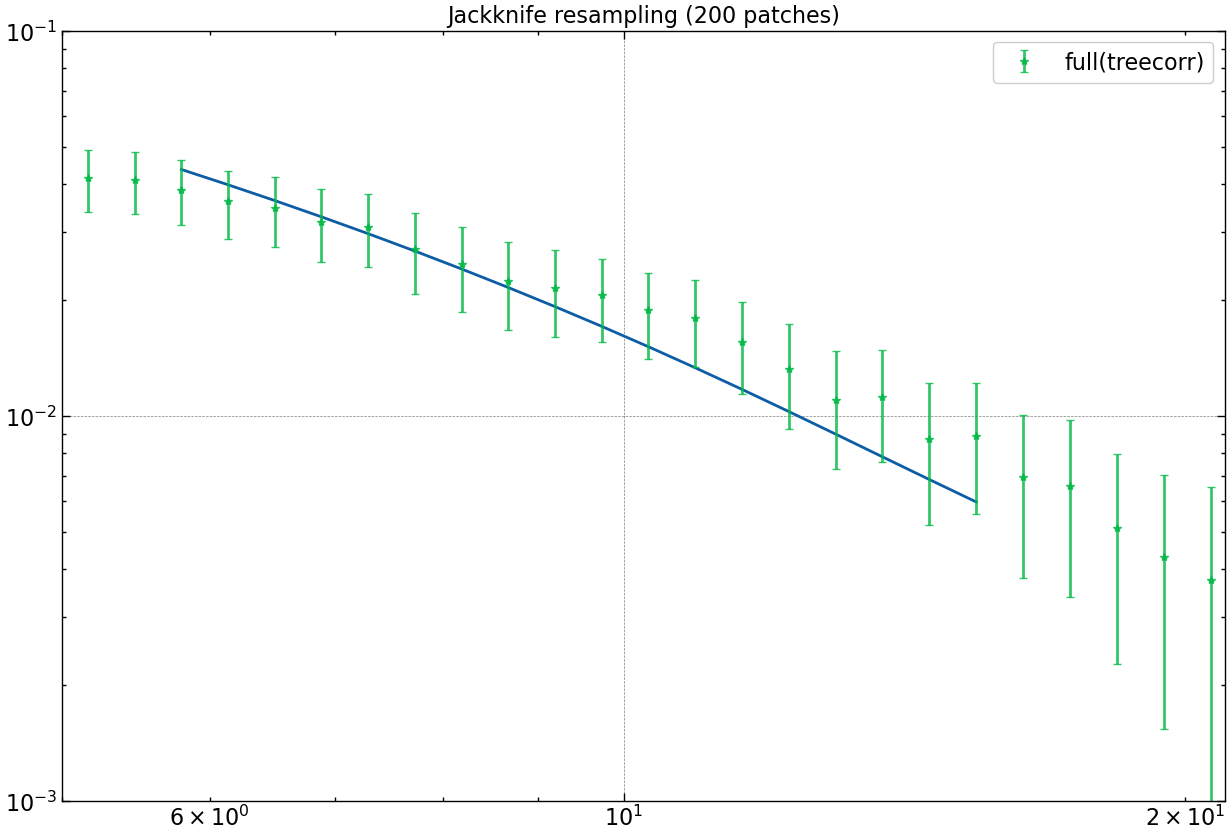

[1.82724364]
[3.33881931]


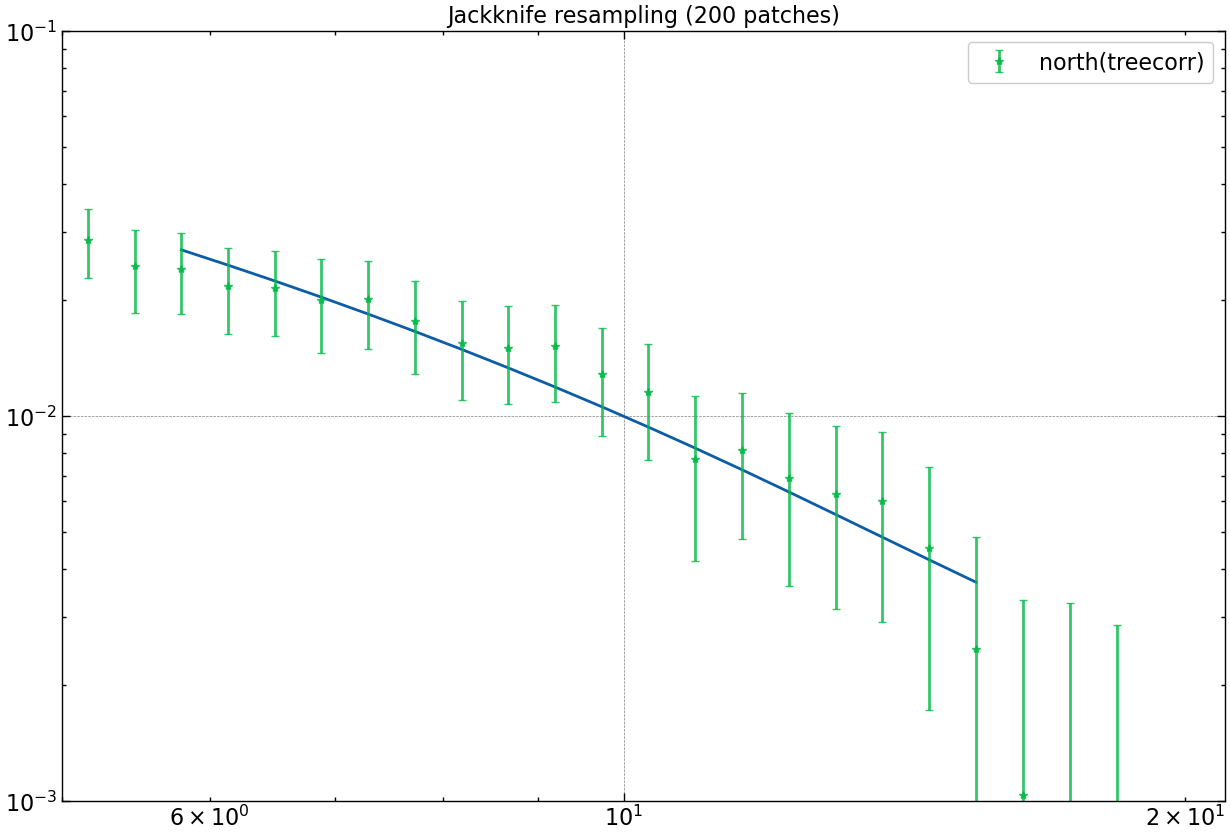

[2.37025629]
[5.61811487]


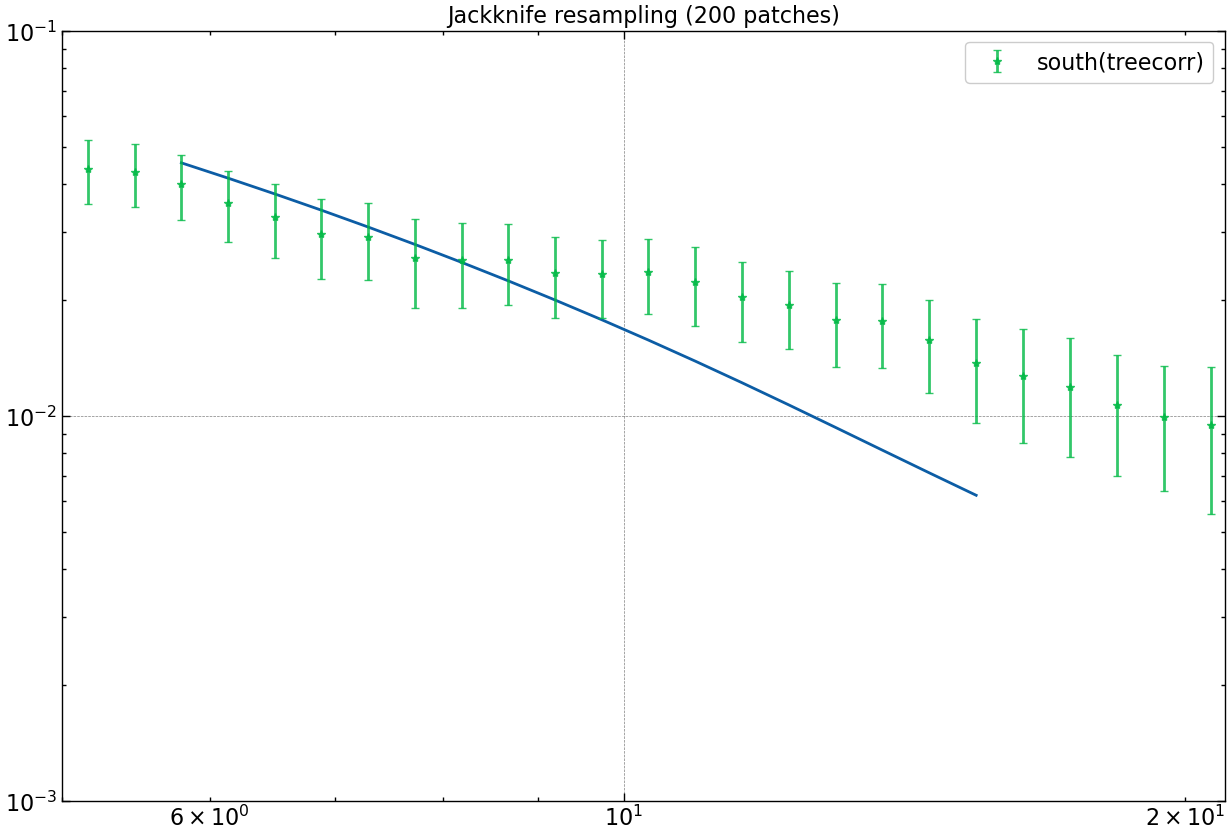

In [52]:
for file in files_jackknife_200:
    fig, ax = plt.subplots(figsize=(15,10))

    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    ax.set_title('Jackknife resampling (200 patches)')
    mask_data= (dat[0]<15.9) & (dat[0]>5.6)
    popt,pcov = cf(wfunc,dat[0][mask_data],dat[1][mask_data])
    print(np.sqrt(popt))
    ax.plot(dat[0][mask_data],wfunc(dat[0][mask_data],*popt))
    ax.errorbar(dat[0],dat[1],yerr=dat[2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
    plt.legend()
    print(popt)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylim(0.001,0.1)
    plt.xlim(5,21)
    plt.show()

In [19]:
files_jackknife = [file for file in files if  'jackknife'  in file and 'corrfunc' in file]
w_estimates_south = np.load(files_jackknife[0])[:,1]
w_estimates_north = np.load(files_jackknife[1])[:,1]
w_estimates_full = np.load(files_jackknife[-1])[:,1]

In [ ]:
# for i in range(w_estimates_north.shape[1]):
#     plt.hist(w_estimates_south[:,i],bins=20)
#     #plt.show()

In [20]:
x_mean_south= np.mean(w_estimates_south,axis=0)
x_mean_north= np.mean(w_estimates_north,axis=0)
x_mean_full = np.mean(w_estimates_full,axis=0)
from matplotlib.colors import LogNorm

C_jk_north=199/200*((w_estimates_north- x_mean_north).T@(w_estimates_north- x_mean_north))
C_jk_south=199/200*((w_estimates_south- x_mean_south).T@(w_estimates_south- x_mean_south))
C_jk_full = 199/200*((w_estimates_full - x_mean_full).T@(w_estimates_full - x_mean_full))
sigma_jk_north=np.sqrt(np.diag(C_jk_north))
sigma_jk_south=np.sqrt(np.diag(C_jk_south))
sigma_jk_full=np.sqrt(np.diag(C_jk_full))

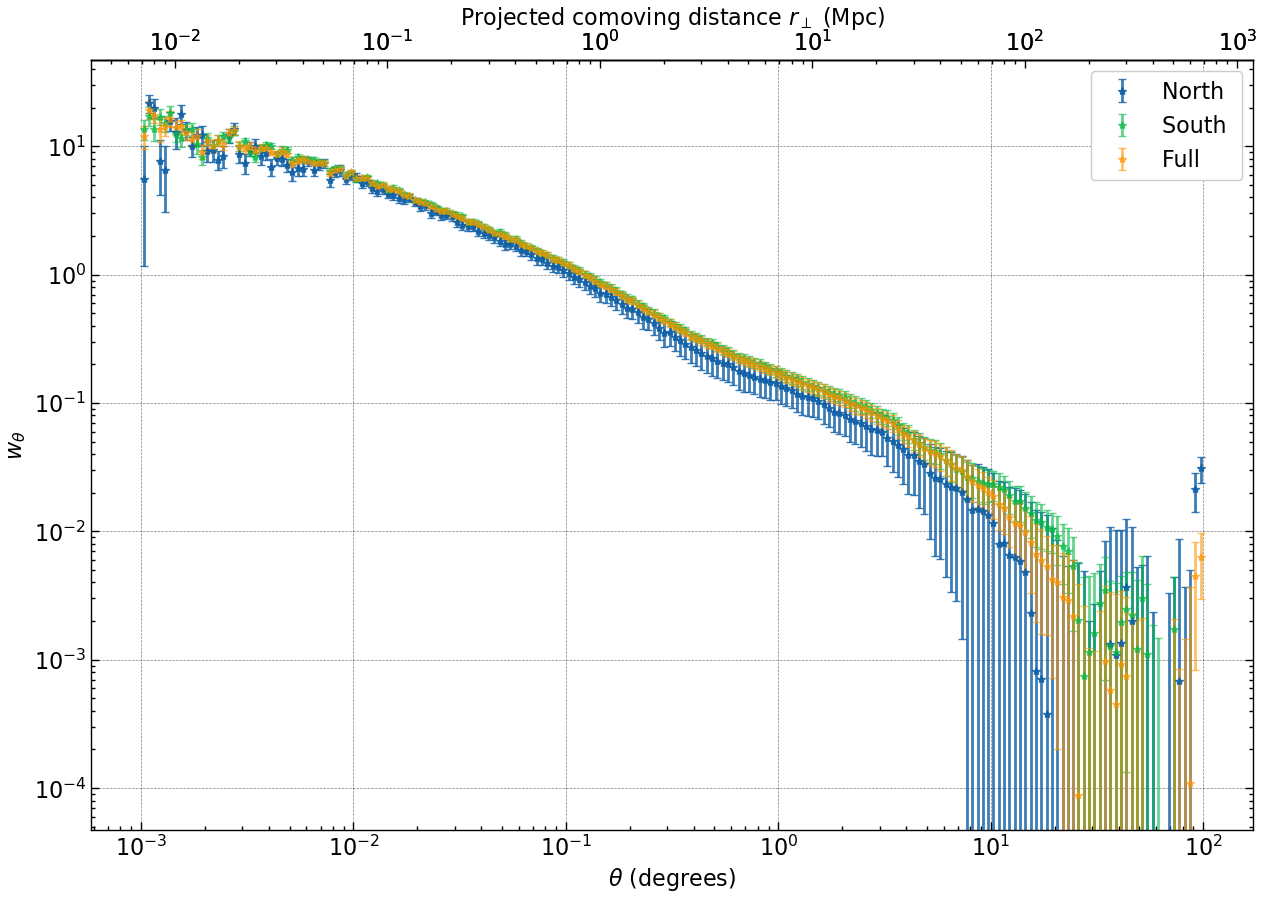

In [21]:
w_theta_north = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy')
w_theta_south = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy')
w_theta_full = np.load('/user/animesh.sah/w_theta_results/corrfunc_full_0.001_to_100.npy')

fig,ax = plt.subplots(figsize=(15,10))
ax.errorbar(w_theta_north[0], w_theta_north[1], yerr=sigma_jk_north,ls='None',marker='*',capsize=3,label = 'North ',alpha=0.8)
ax.errorbar(w_theta_south[0], w_theta_south[1], yerr=sigma_jk_south,ls='None',marker='*',capsize=3,label = 'South ',alpha=0.6)
ax.errorbar(w_theta_full[0], w_theta_full[1], yerr=sigma_jk_full,ls='None',marker='*',capsize=3,label = 'Full ',alpha=0.6)

secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
plt.legend()
plt.savefig('w_theta_jackknife_north_south.png')
plt.show()

In [22]:
files_point = np.sort([file for file in files if  'jackknife'  not in file and 'bootstrap' not in file and  '0.001_to_100' in file and 'corrfunc' in file  and 'full' not in file])
files_point

array(['/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy'],
      dtype='<U65')

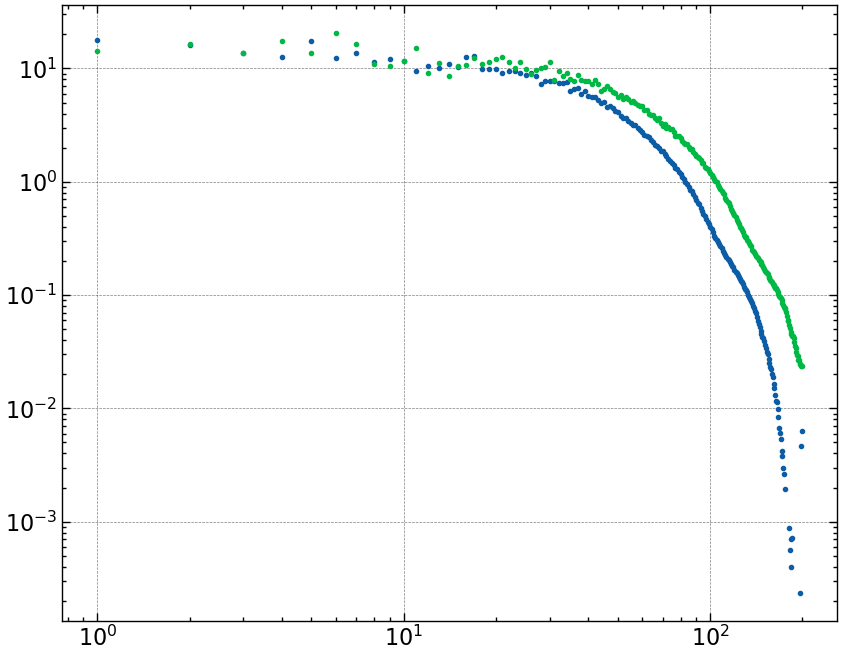

In [23]:
plt.figure(figsize=(10,8))
plt.loglog(np.mean(w_estimates_south,axis = 0),'.')
plt.loglog(np.mean(w_estimates_north,axis = 0),'.')



Text(0.5, 1.0, 'Jackknife resampling')

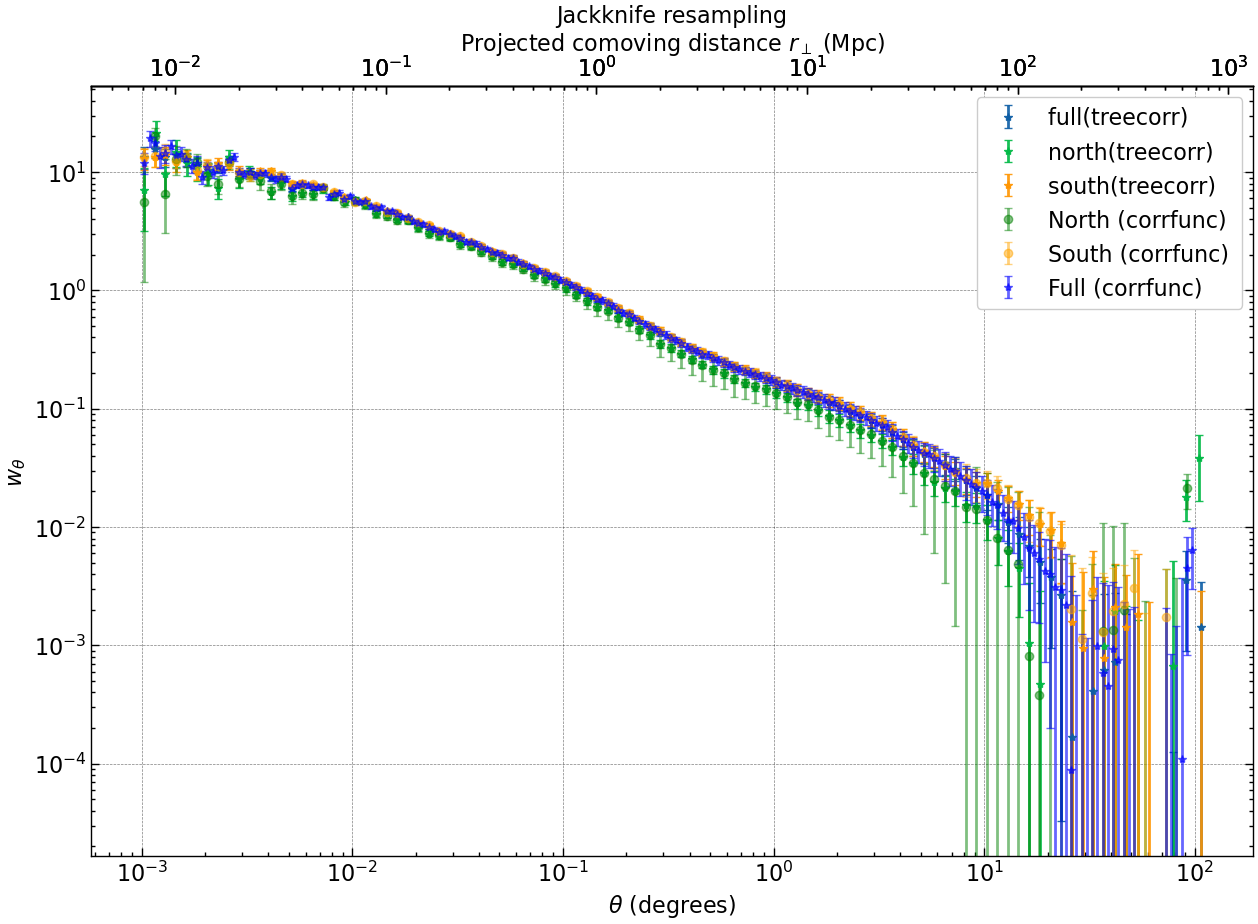

In [24]:
files= glob.glob('/user/animesh.sah/w_theta_results/*')

files_jackknife_200 = np.sort([file for file in files if  'jackknife'  in file and '200' in file ])

#files_bootstrap = np.sort([file for file in files if  'bootstrap'  in file])
#part = ['north','south','full']


#{patch: [file for file in files if patch in file] for patch in part}

#plt.figure(figsize=(15,10))
fig, ax = plt.subplots(figsize=(15,10))

for file in files_jackknife_200:
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    #ax.set_title('Jackknife resampling (200 patches)')
    ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=f'{name} ',marker='*',linestyle='None',capsize=3,alpha=0.9)
ax.set_xscale('log')

ax.set_yscale('log')
ax.errorbar(w_theta_north[0][::2], w_theta_north[1][::2], yerr=sigma_jk_north[::2],ls='None',marker='o',color='green',capsize=3,label = 'North (corrfunc) ',alpha=0.5)
ax.errorbar(w_theta_south[0][::2], w_theta_south[1][::2], yerr=sigma_jk_south[::2],ls='None',marker='o',color='orange',capsize=3,label = 'South (corrfunc)',alpha=0.5)
ax.errorbar(w_theta_full[0], w_theta_full[1], yerr=sigma_jk_full,ls='None',marker='*',color='b',capsize=3,alpha=0.6,label ='Full (corrfunc)')

secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()
plt.title('Jackknife resampling')

In [ ]:
w_theta

In [9]:
import pyarrow.parquet as pq
bootstrap = pq.read_table("/user/animesh.sah/DESI_PECVEL/bootstrap_results.parquet")
k = bootstrap.column("bootstrap_test").to_pylist()   # returns list of lists/arrays
lst_boot = np.vstack(k)


mean_lst = np.mean(lst_boot,axis=0)
cov_boot = (1/9999)*((lst_boot- mean_lst).T@(lst_boot- mean_lst))
sigma_boot=np.sqrt(np.diag(cov_boot))
plt.plot(mean_lst,'.')
# lst_boot
# mean=[]
# std=[]
# for i in range(20):
#     plt.hist(lst_boot[:,i],bins=30,edgecolor='k',alpha=0.5)
#     #plt.axvline(W[i],color='r',ls='-.')
#     mean.append(lst_boot[:,i].mean())
#     std.append(lst_boot[:,i].std())
#     plt.show()

FileNotFoundError: /user/animesh.sah/DESI_PECVEL/bootstrap_results.parquet

In [25]:
north = np.load('/user/animesh.sah/w_theta_results/treecorr_north_none_patches_100_0.001_to_10.npy')
south = np.load('/user/animesh.sah/w_theta_results/treecorr_south_none_patches_100_0.001_to_10.npy')

In [26]:
w_0_03=np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.03.npy')
w_min0_0234 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_-0.0234.npy')
w_0_04=np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.04.npy')
w_0_0234 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.023.npy')


In [27]:
w_min_0_04 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_min_0.04_v2.npy')
w_0_04 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.04_v2.npy')
w_0_0234 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.0234_v2.npy')
w_0_01 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.01_v2.npy')

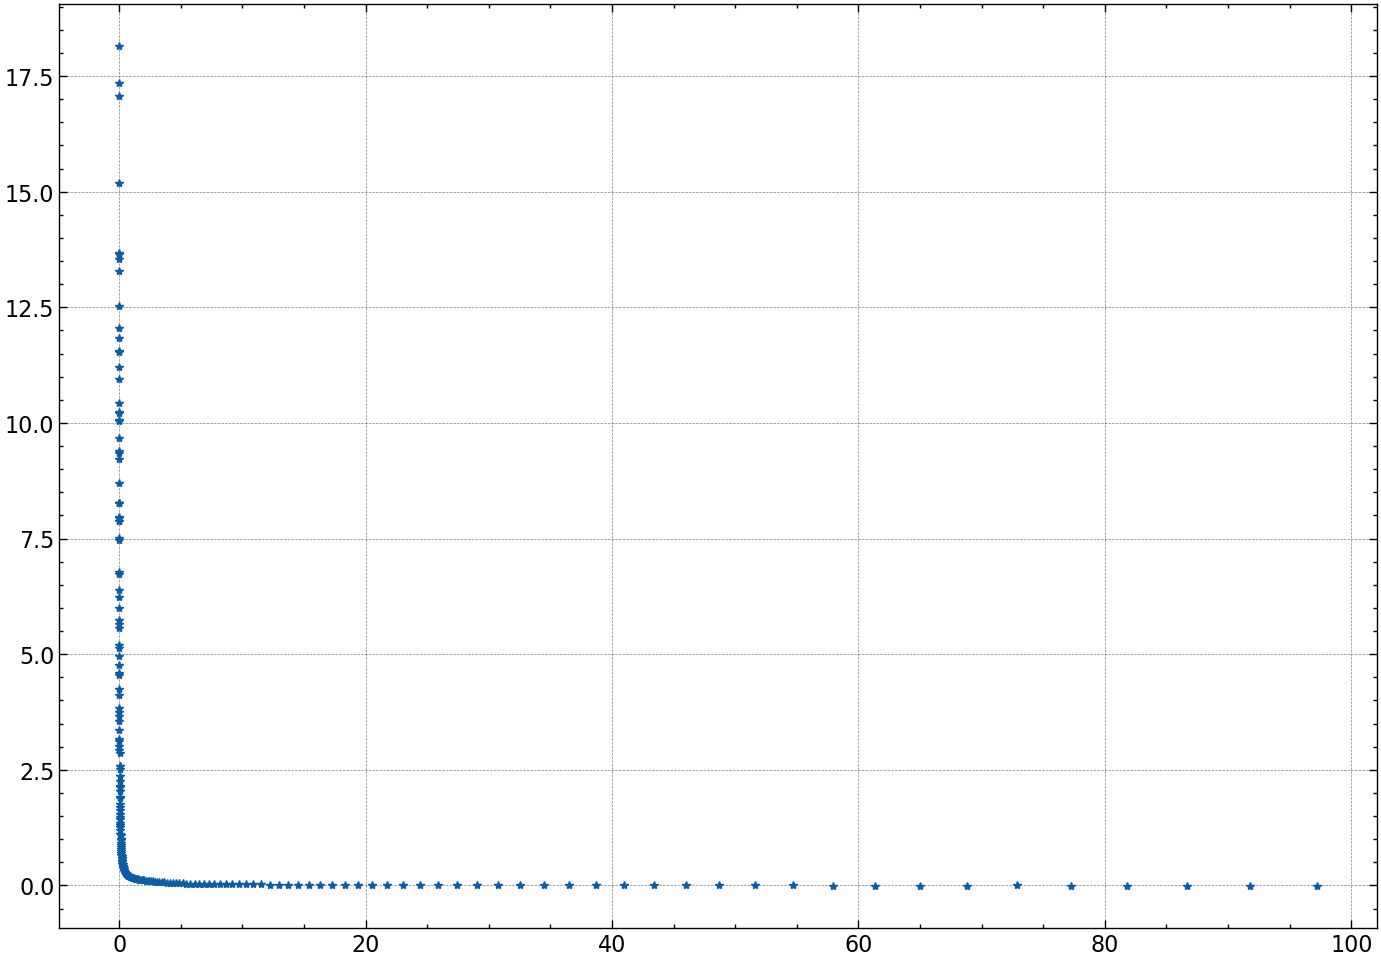

In [28]:
color = ['k','r','b','g']
fig,ax = plt.subplots(figsize=(17,12))
for file in ['/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy']: 
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    if  'corrfunc' in name:
        ax.plot(dat[0],dat[1],label=name,marker='*',linestyle='None')
    else: 
        ax.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')

In [30]:
north = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy')
south = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy')
north_bestfit = np.load('/user/animesh.sah/DESI_PECVEL/w_theta_minimized.npy')


north_bestfits={}
for i in range(2,8):
    north_bestfits[i] = np.load(f'/user/animesh.sah/DESI_PECVEL/w_theta_minimized_v{i}.npy')

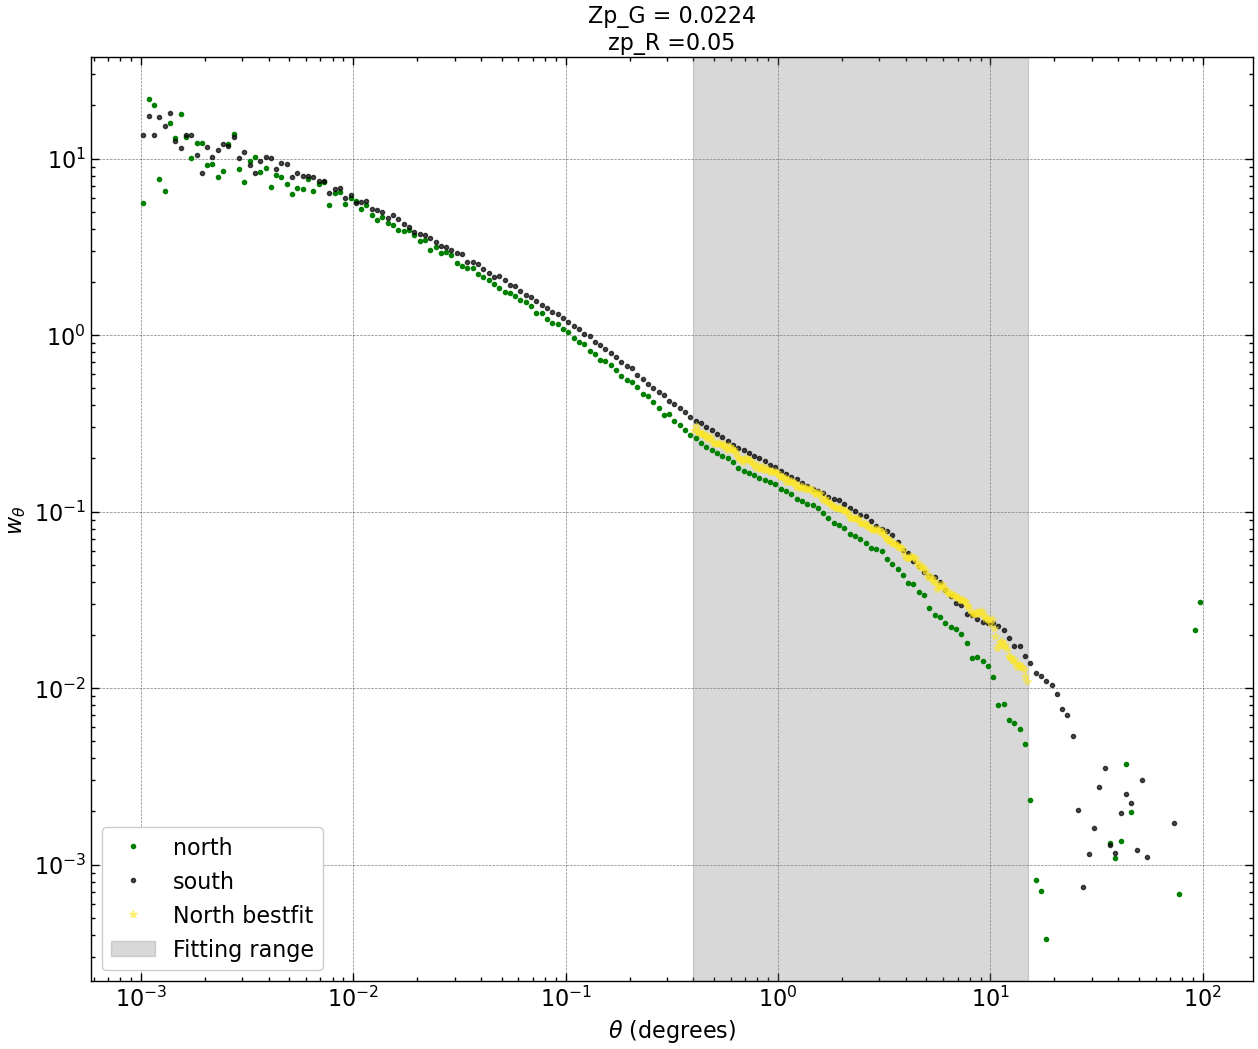

In [31]:
colors = plt.cm.RdBu(np.linspace(0, 1, 4))

plt.figure(figsize=(15,12))
# plt.plot(w_min_0_04[0],w_min_0_04[1],'*',label='-0.04',color=colors[0],alpha=0.4)
# plt.plot(w_0_01[0],w_0_01[1],'*',label='0.01',color=colors[1],alpha=0.4)
# plt.plot(w_0_0234[0],w_0_0234[1],'*',label='0.0234',color=colors[2],alpha=0.4)

# plt.plot(w_0_04[0],w_0_04[1],'*',label='0.04',color = colors[3],alpha=0.4)
# plt.plot(w_0_0234[0],w_0_0234[1],'*')
# plt.plot(w_0_03[0],w_0_03[1],'*')
plt.xscale('log')
plt.yscale('log')
#dat = np.load(file)
#plt.plot(south[0],south[1],marker='.',linestyle='None',label='south',color='k',alpha=0.7)
plt.plot(north[0],north[1],marker='.',linestyle='None',label='north',color='g')
#plt.plot(north_bestfit[0],north_bestfit[1],marker='*',linestyle='None',label='North bestfit zp')
plt.plot(south[0],south[1],marker='.',linestyle='None',label='south',color='k',alpha=0.7)


colors  = plt.cm.viridis(np.linspace(0,1,6))
for i, (version, data) in enumerate(north_bestfits.items()):
    if i==5:
        plt.plot(data[0], data[1], marker='*', linestyle='None', label=f'North bestfit', color=colors[i], alpha=0.5)
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{\theta}$')
plt.title('Zp_G = 0.0224\nzp_R =0.05')
plt.axvspan(xmin=.4, xmax=15, color='gray', alpha=0.3, label='Fitting range')
plt.plot()
plt.legend()

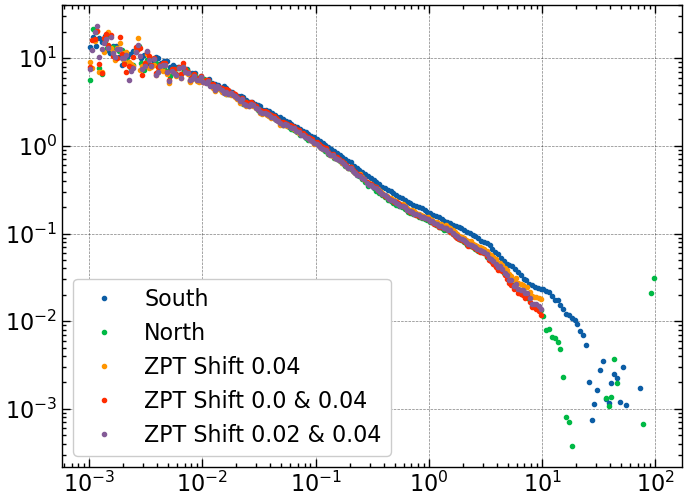

In [18]:
plt.plot(south[0],south[1],'.',label='South')
plt.plot(north[0],north[1],'.',label='North')

zpt_shift_0_04 = np.load('/user/animesh.sah/DESI_PECVEL/0.04_zpshift.npy')
zpt_shift_0 = np.load('/user/animesh.sah/DESI_PECVEL/zero_zpshift.npy')
zpt_shift_00_0_04 = np.load('/user/animesh.sah/DESI_PECVEL/0.0_0.04_zpshift.npy')
zpt_shift_0_02_0_04 = np.load('/user/animesh.sah/DESI_PECVEL/0.02_0.04_zpshift.npy')
plt.plot(zpt_shift_0_04[0], zpt_shift_0_04[1], '.', label='ZPT Shift 0.04')
#plt.plot(zpt_shift_0[0], zpt_shift_0[1], '.', label='ZPT Shift 0')
plt.plot(zpt_shift_00_0_04[0], zpt_shift_00_0_04[1], '.', label='ZPT Shift 0.0 & 0.04')
plt.plot(zpt_shift_0_02_0_04[0], zpt_shift_0_02_0_04[1], '.', label='ZPT Shift 0.02 & 0.04')
plt.xscale('log')
plt.yscale('log')
plt.legend()


In [32]:
w_theta= np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10.npy')


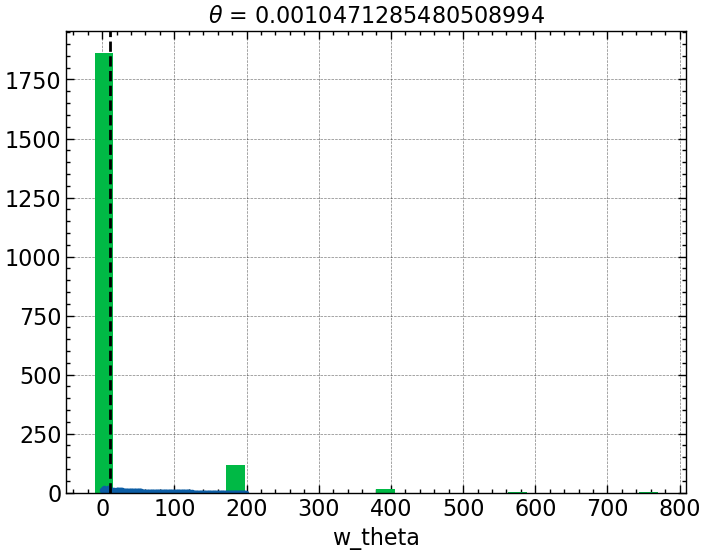

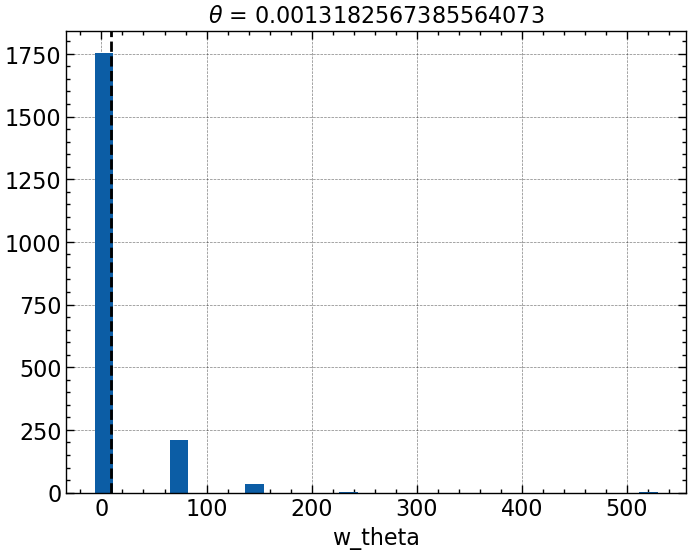

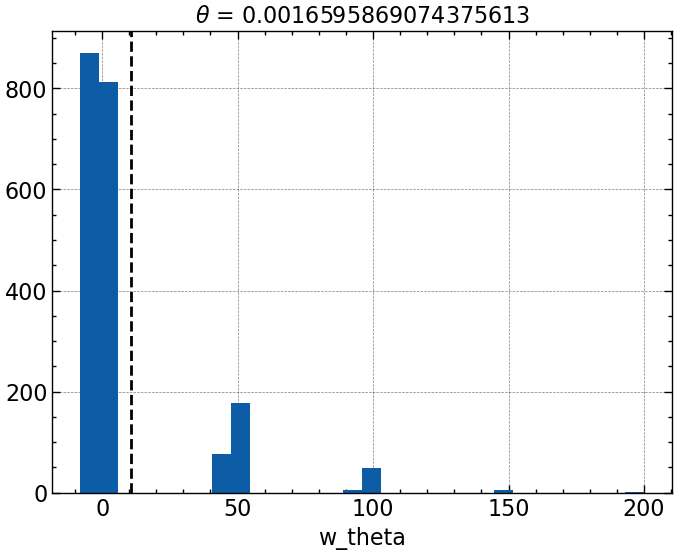

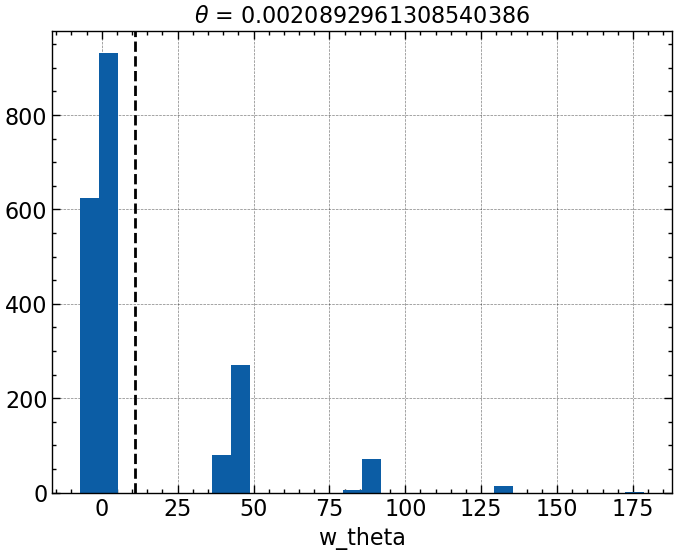

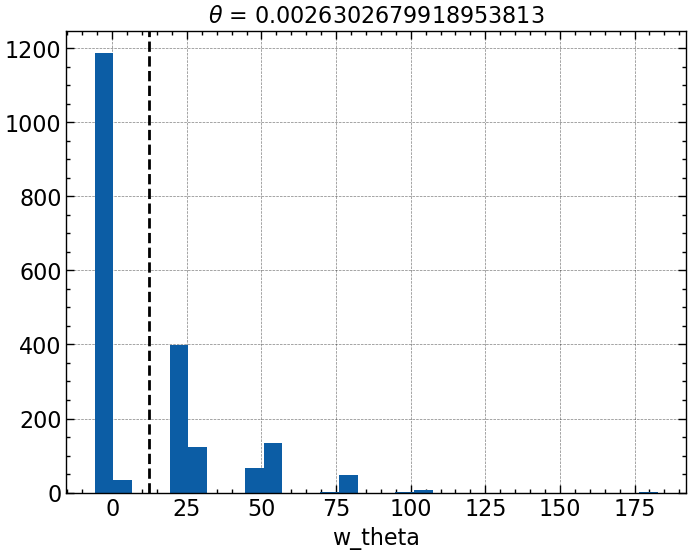

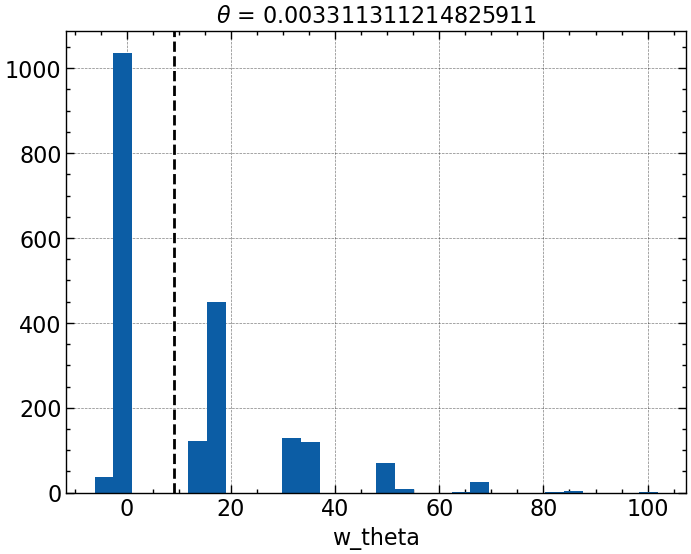

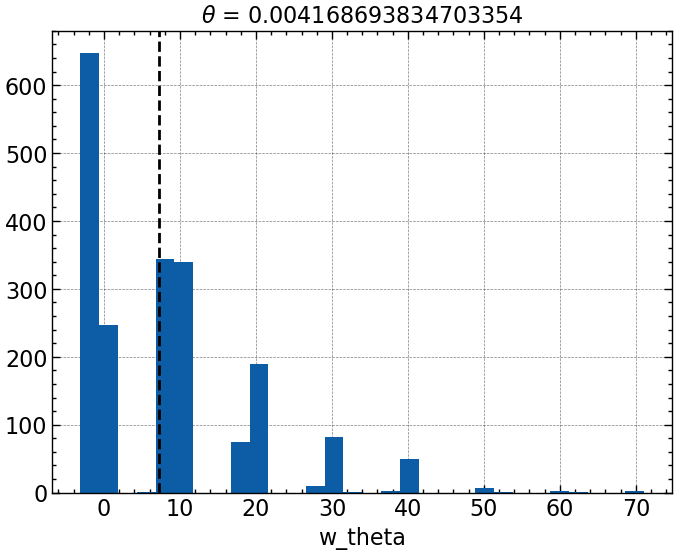

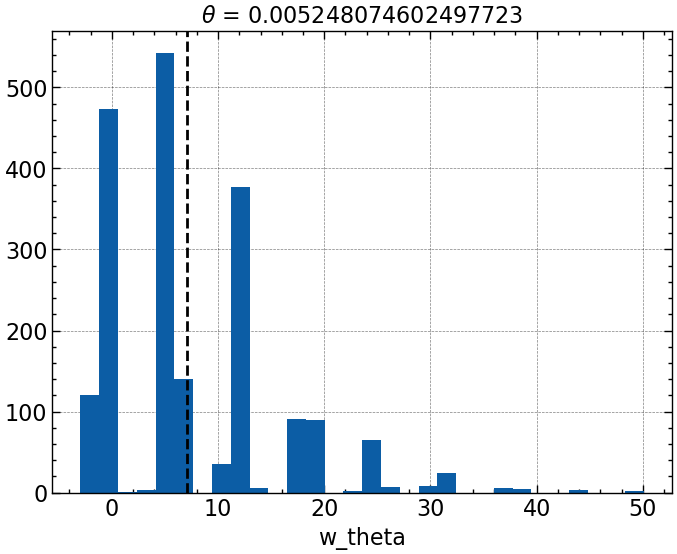

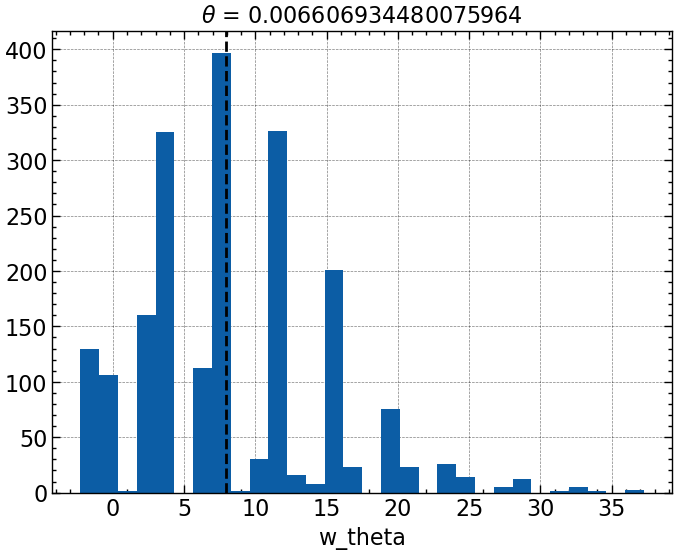

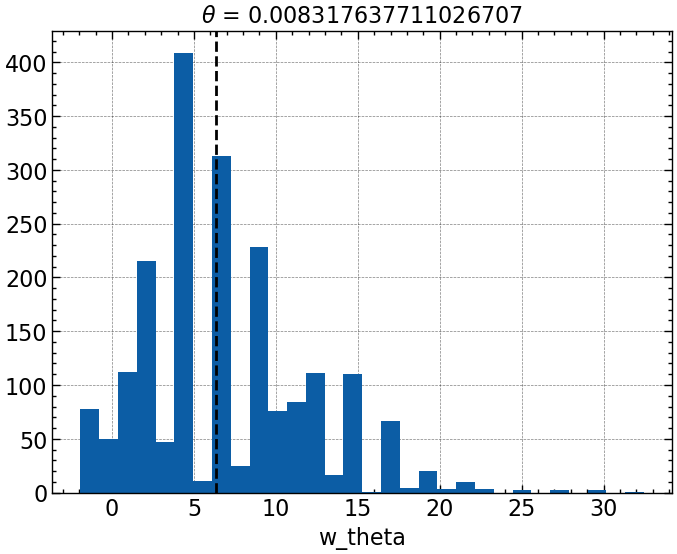

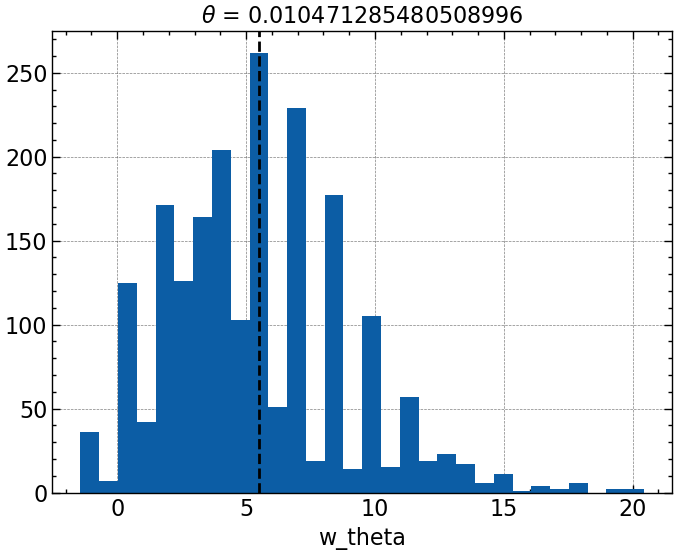

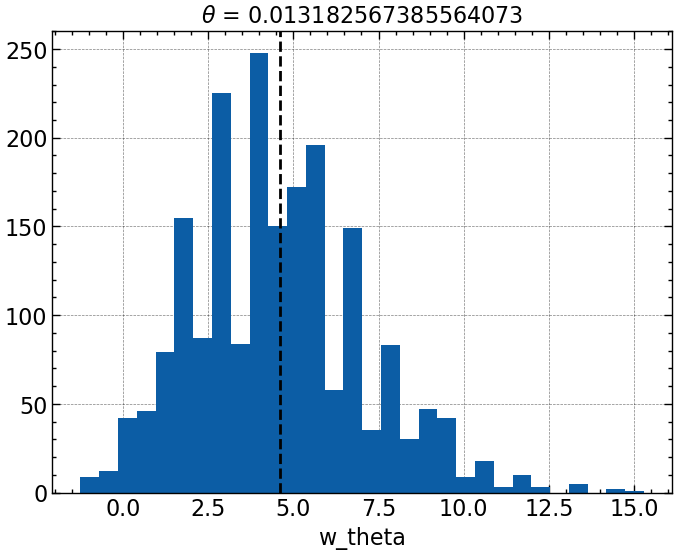

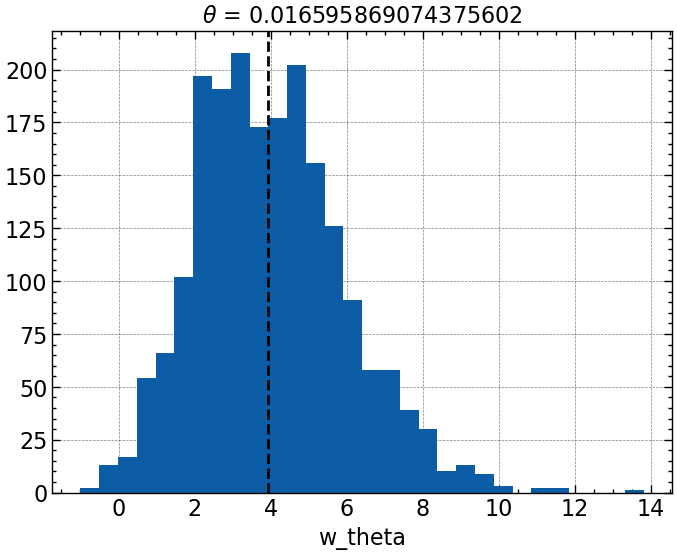

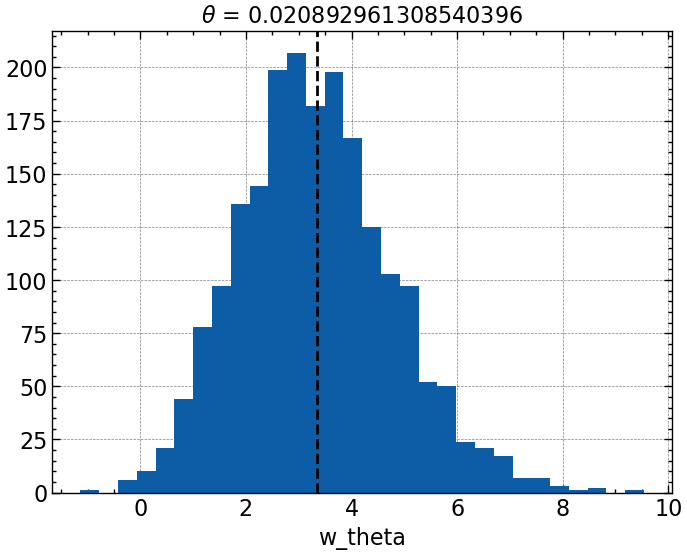

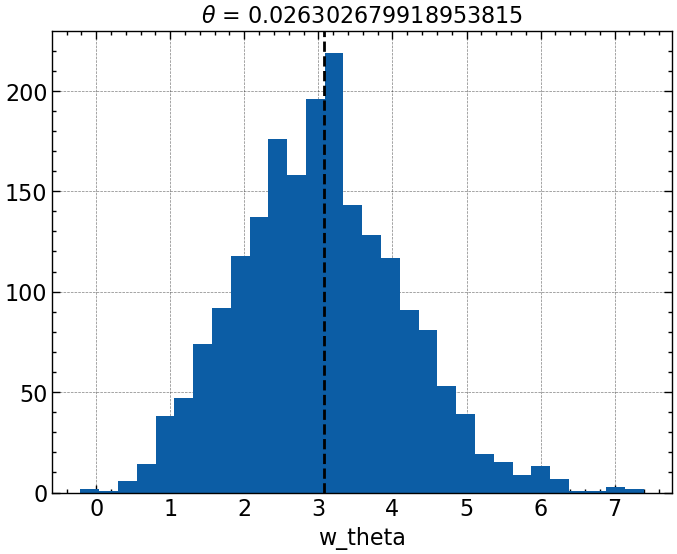

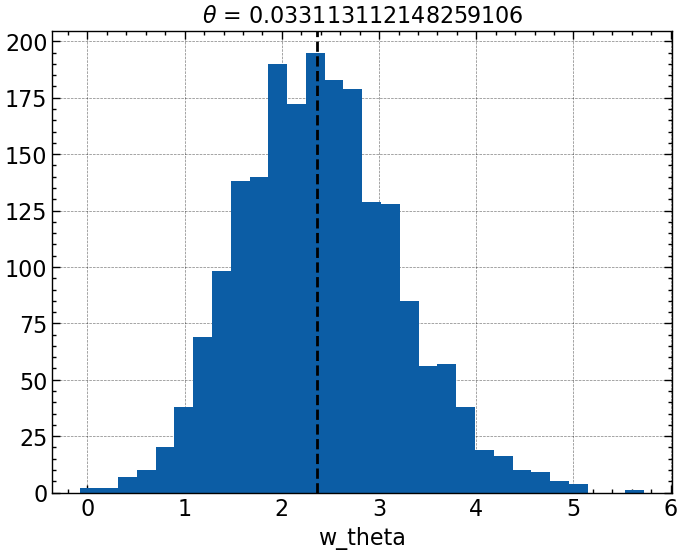

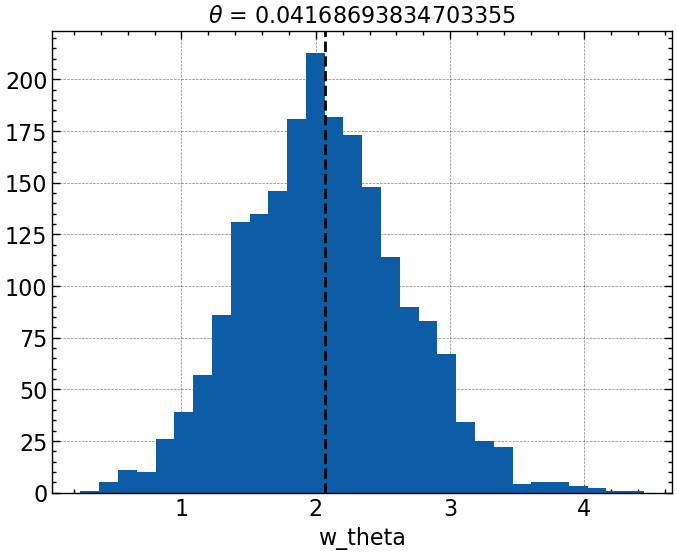

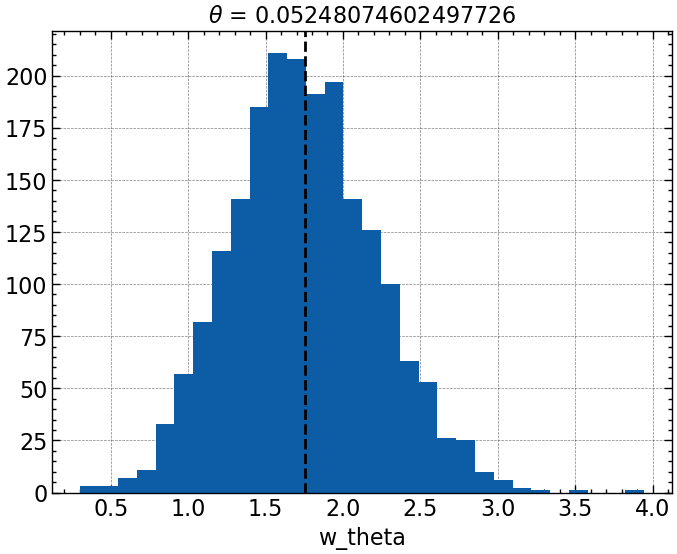

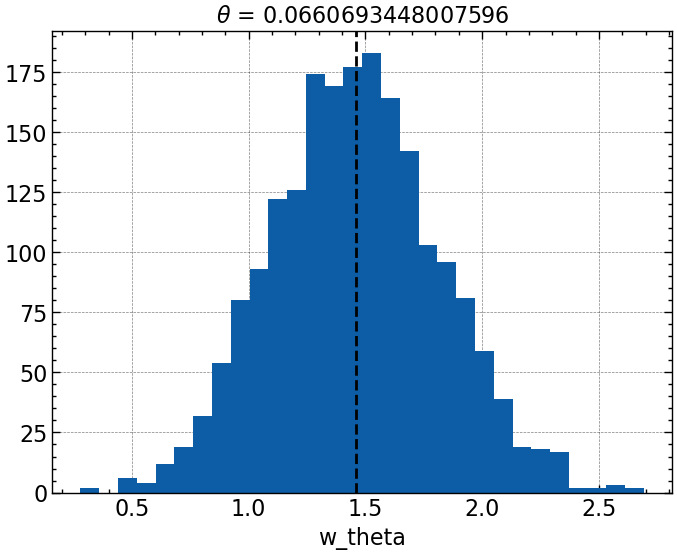

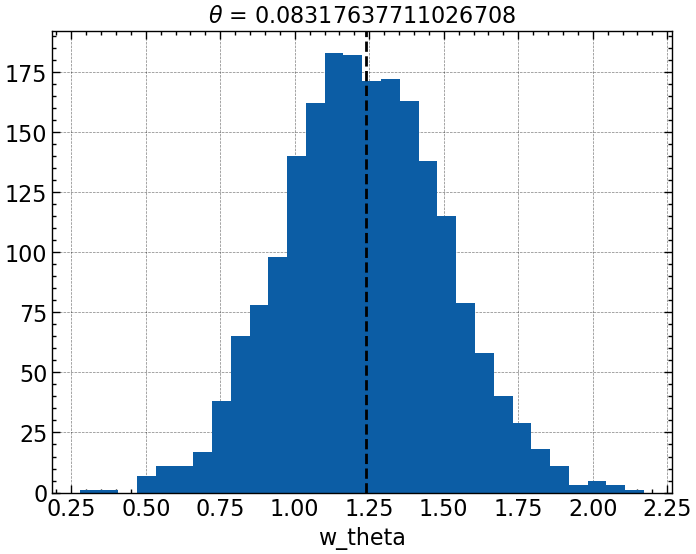

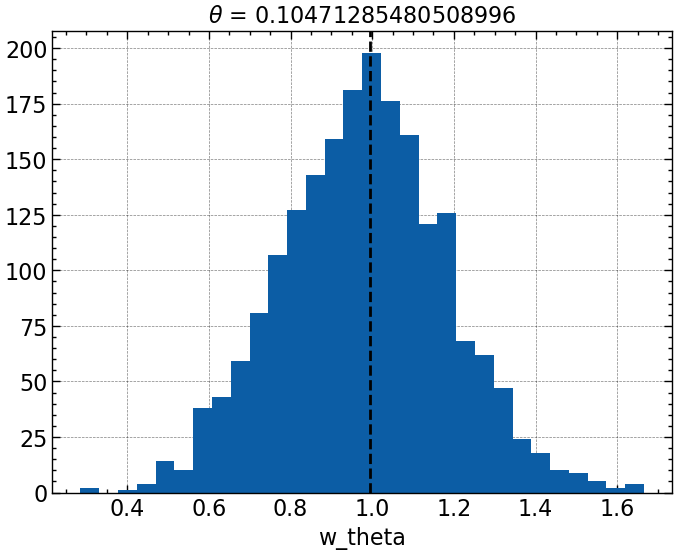

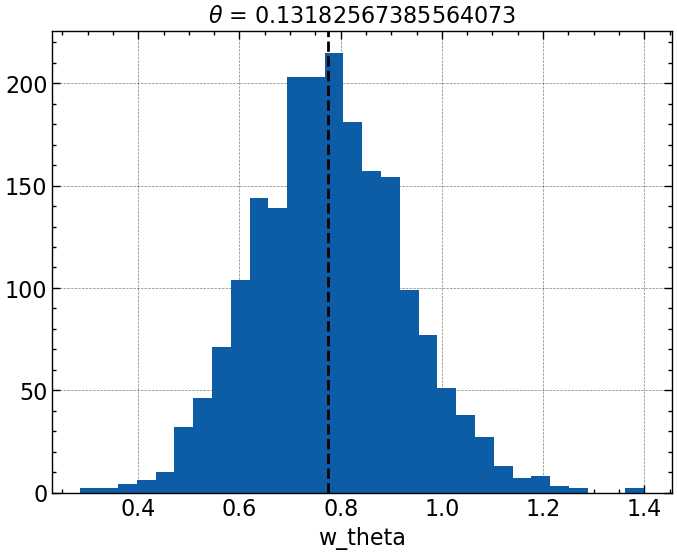

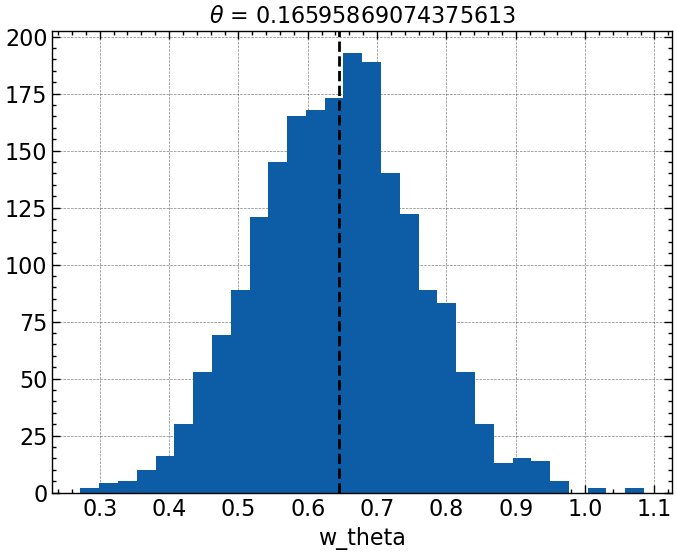

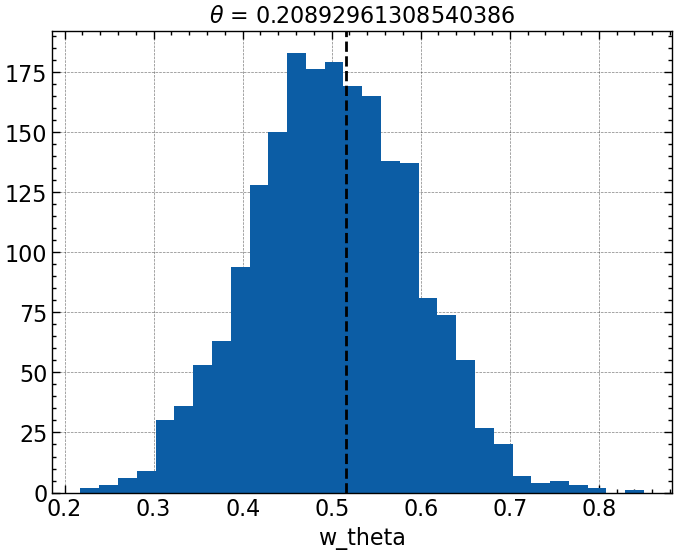

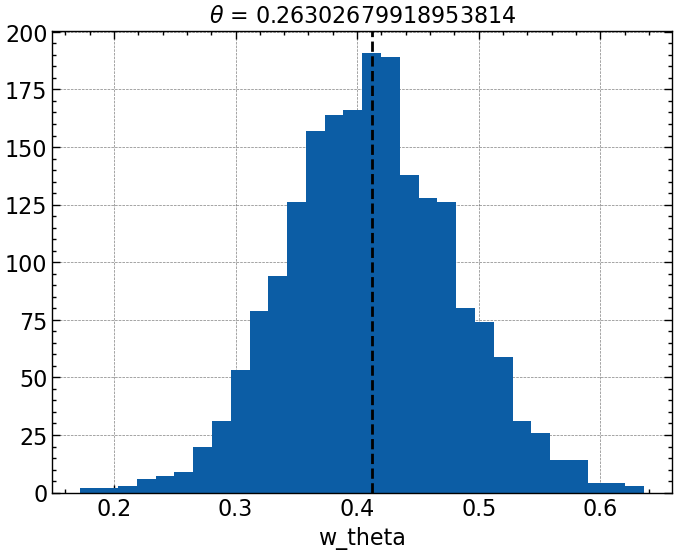

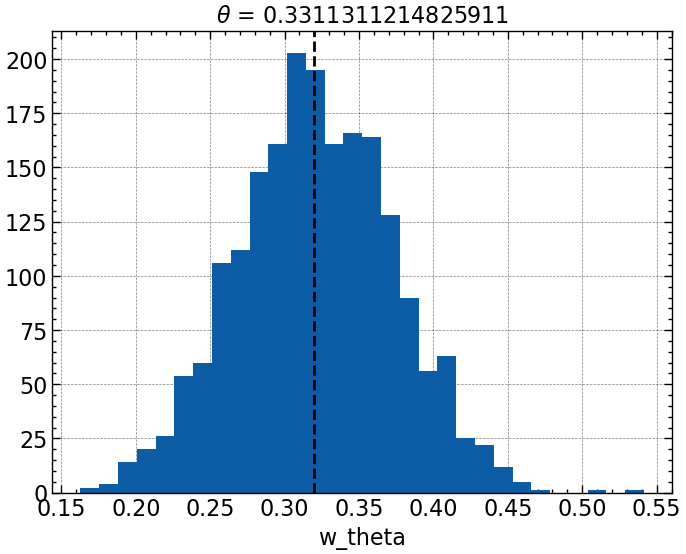

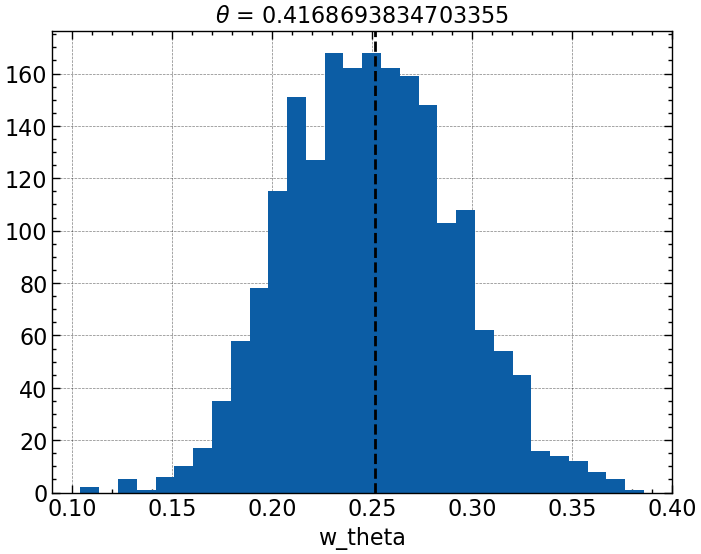

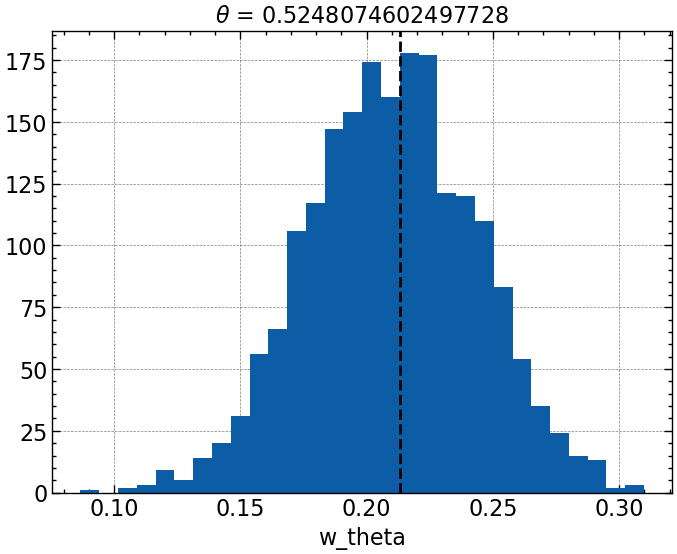

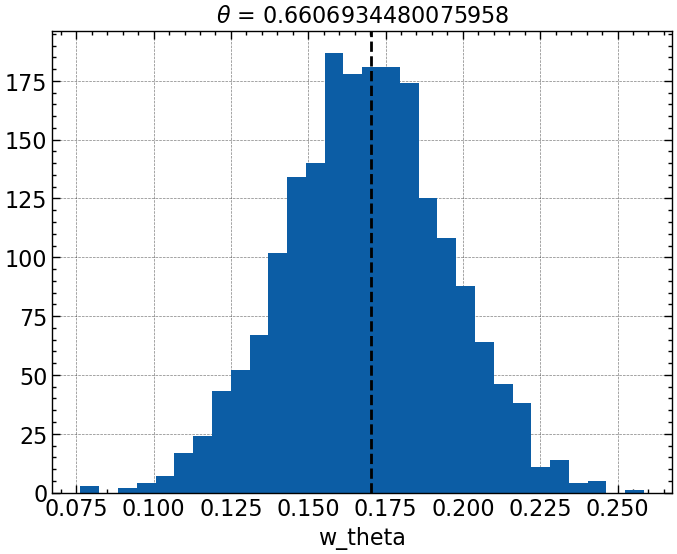

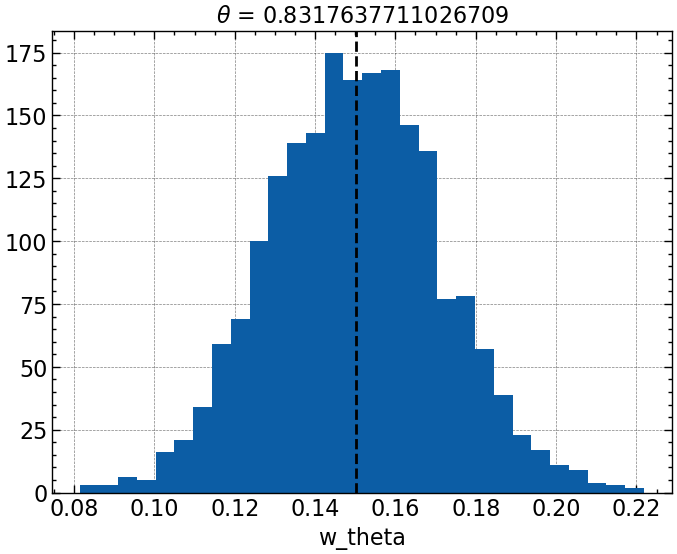

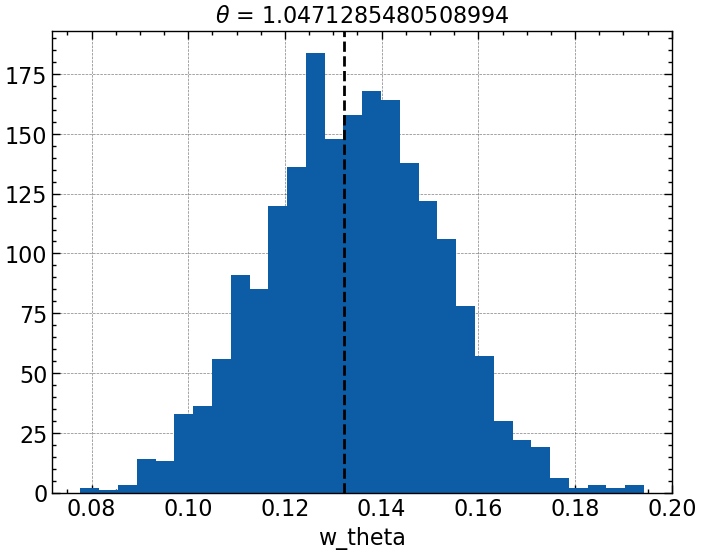

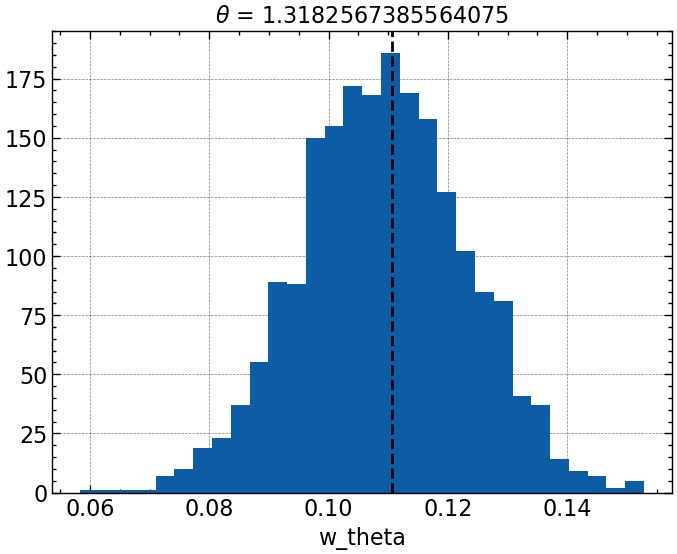

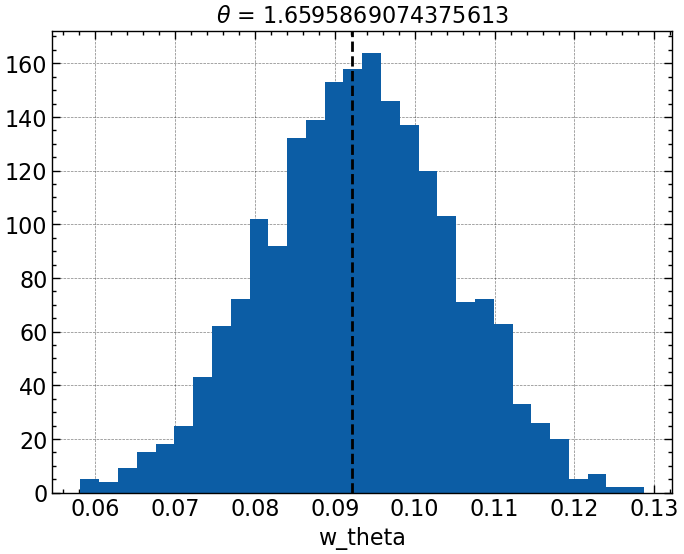

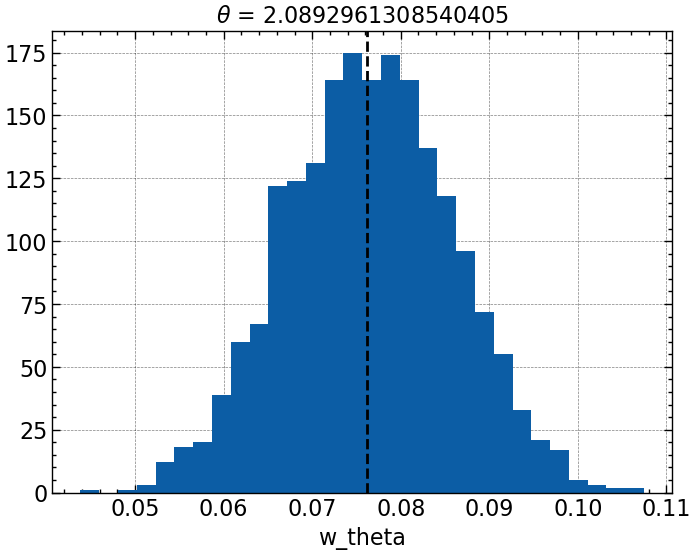

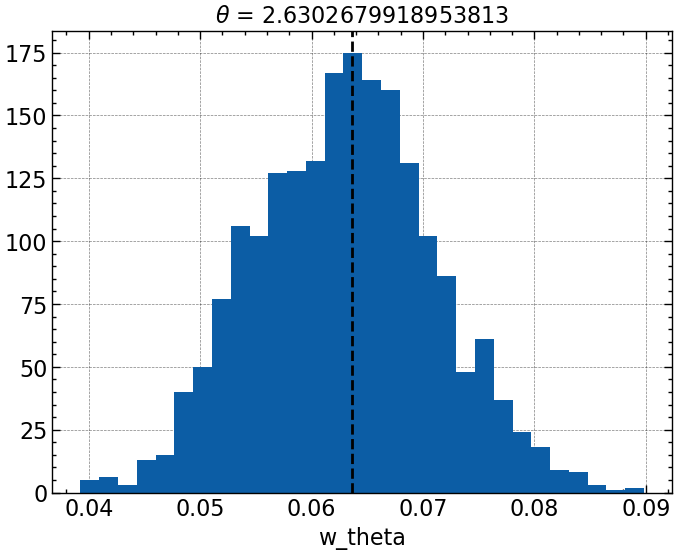

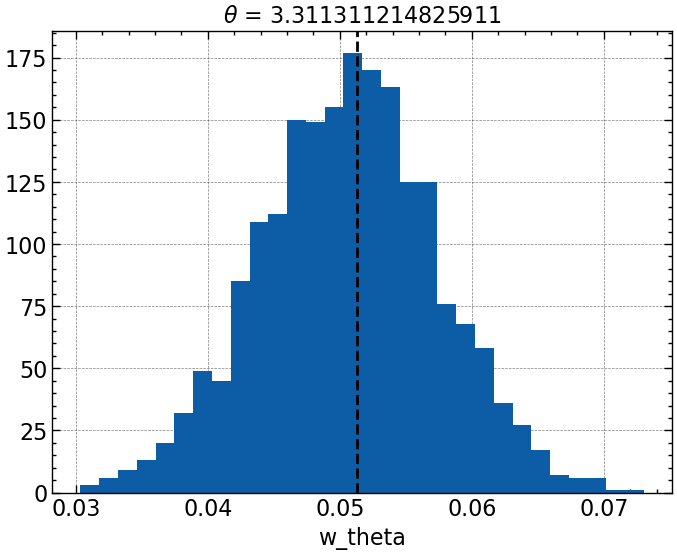

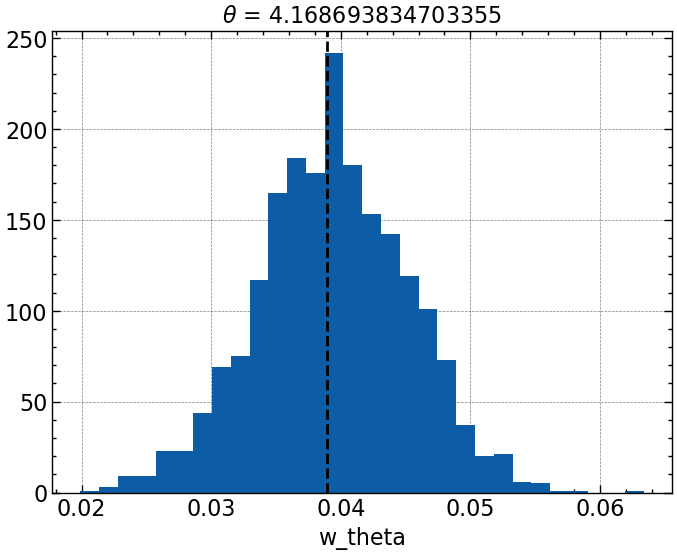

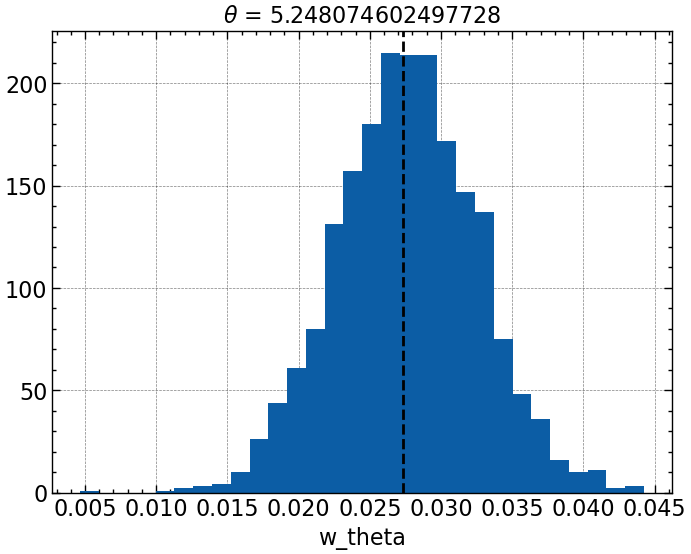

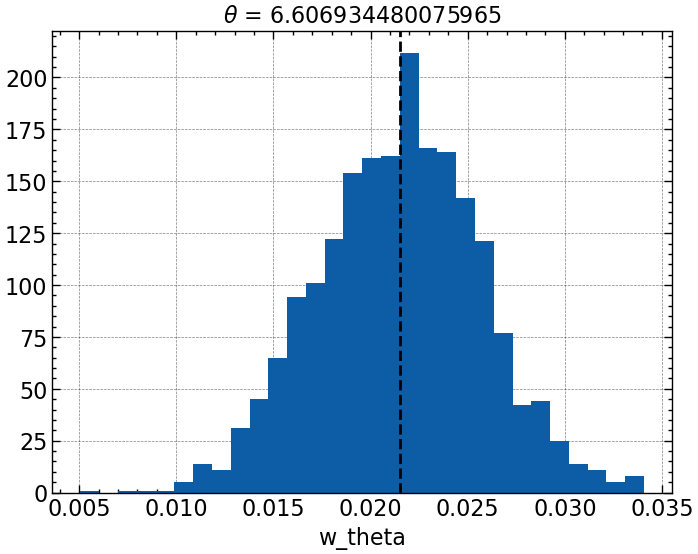

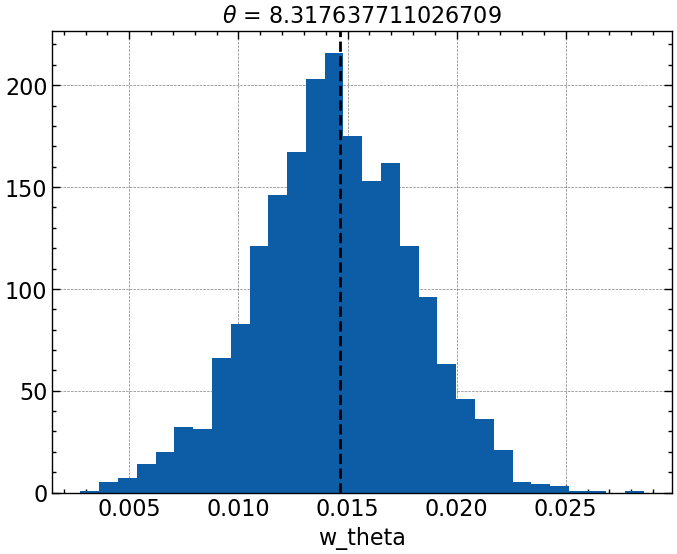

In [12]:
north=np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap__num_bootstrap_2000_0.001_to_10_v2.npy')
th=np.logspace(np.log10(0.001), np.log10(10), 200+1 )
plt.plot(np.mean(north,axis=0),'.')
for i in range(1,north.shape[1],5):
    plt.hist(north[:,i],bins=30)
    plt.title(r'$\theta$ = '+str(th[i]))
    plt.axvline(w_theta[1][i],color='k',ls='--')
    plt.xlabel('w_theta')
    plt.show()

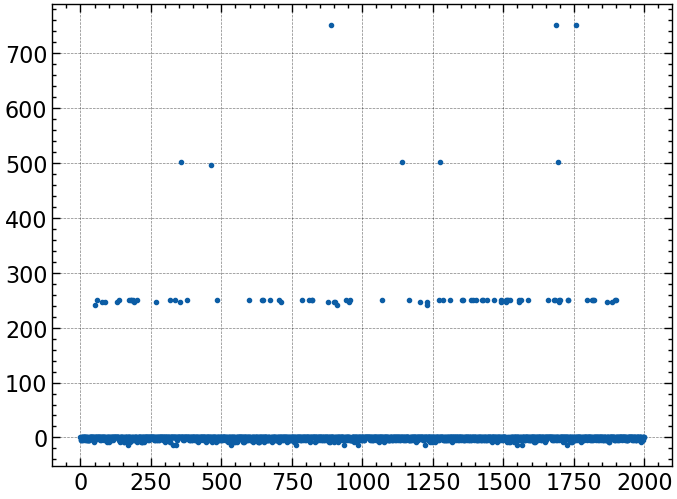

In [ ]:
plt.plot(north[:,0],'.')

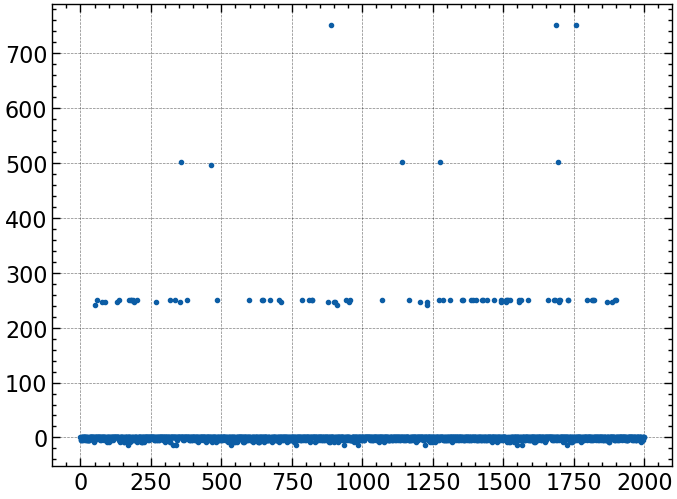

In [ ]:
plt.plot(north[:,0],'.')

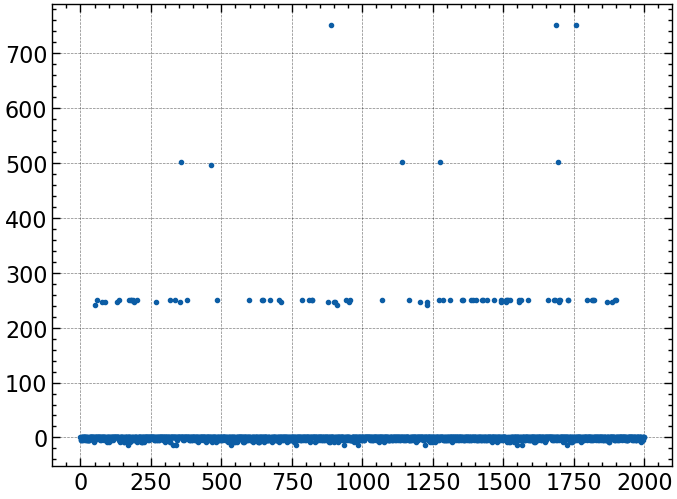

In [ ]:
plt.plot(north[:,0],'.')

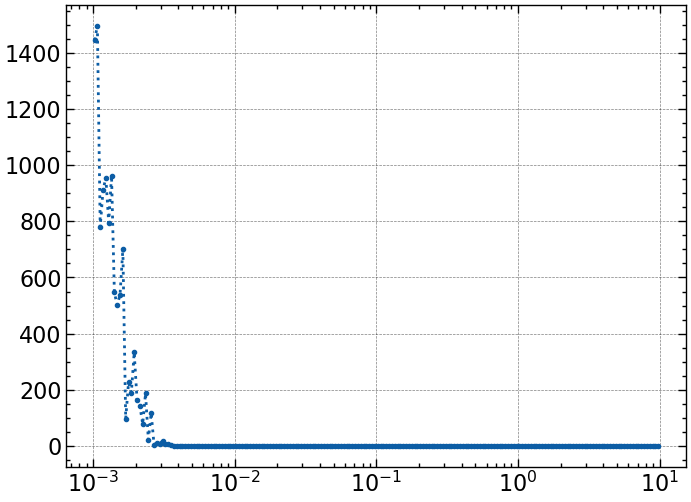

In [13]:

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(north[:,i]==1) for i in range(north.shape[1])],'.:')
#plt.yscale('log')
plt.xscale('log')

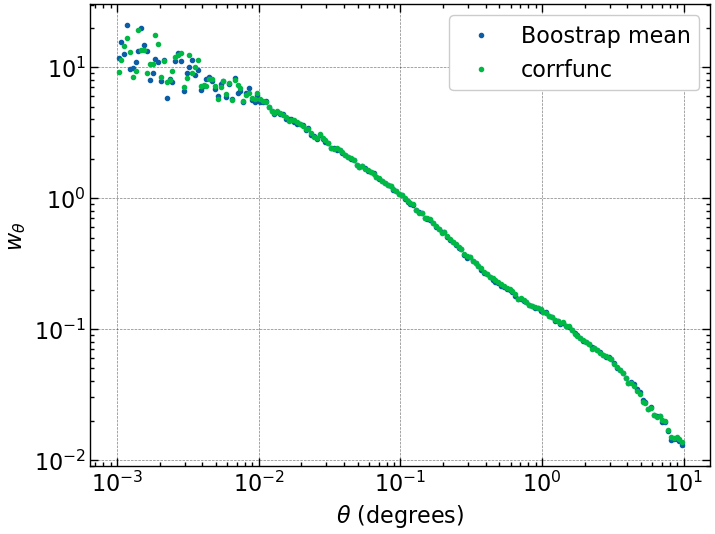

In [16]:
plt.plot(w_theta[0],north.mean(axis=0),'.',label='Boostrap mean')
plt.plot(w_theta[0],w_theta[1],'.',label='corrfunc')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{\theta}$')
plt.legend()

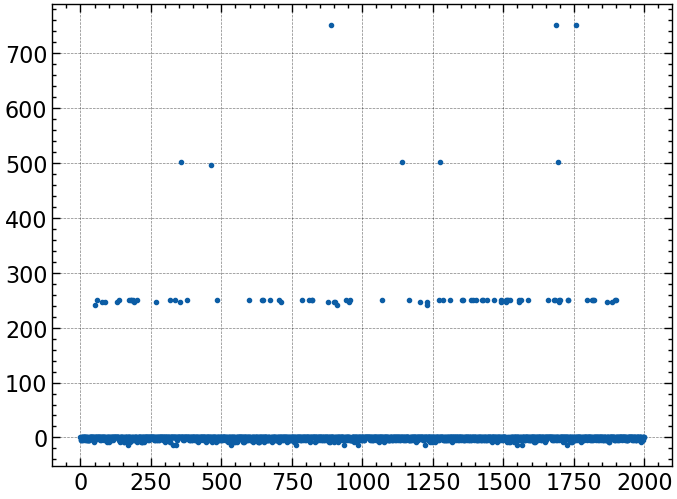

In [29]:
plt.plot(north[:,0],'.')

In [30]:
np.count_nonzero(north[0]==1)

3

In [17]:
w_theta_north_by5 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by5.npy')
w_theta_north_by10 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by10.npy')
w_theta_north_by2 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by2.npy')
w_theta_north_by1 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by1.npy')
th = np.logspace(np.log10(0.001), np.log10(1), 200+1 )

(0.0009, 0.01)

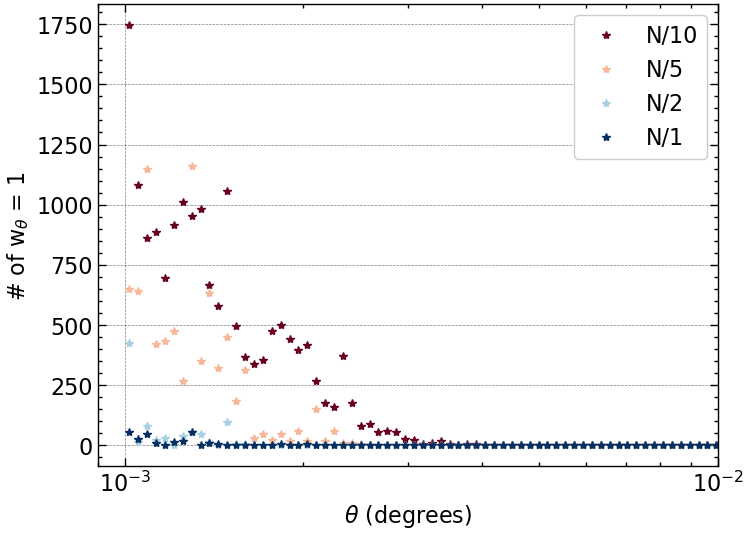

In [18]:
colors = plt.cm.RdBu(np.linspace(0, 1, 4))
plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by10[:,i]==1) for i in range(w_theta_north_by10.shape[1])],'*',color=colors[0],label='N/10')

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by5[:,i]==1) for i in range(w_theta_north_by5.shape[1])],'*',color=colors[1],label='N/5')
plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by2[:,i]==1) for i in range(w_theta_north_by2.shape[1])],'*',color=colors[2],label='N/2')

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by1[:,i]==1) for i in range(w_theta_north_by1.shape[1])],'*',color=colors[3],label='N/1')

plt.xscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'# of w$_\theta$ = 1')
plt.legend()
plt.xlim(9e-4,1e-2)
#plt.title('For N/5')
#plt.yscale('log')

In [21]:
len(w_theta_north_by10[:,i])

2000

(0.0009, 0.05)

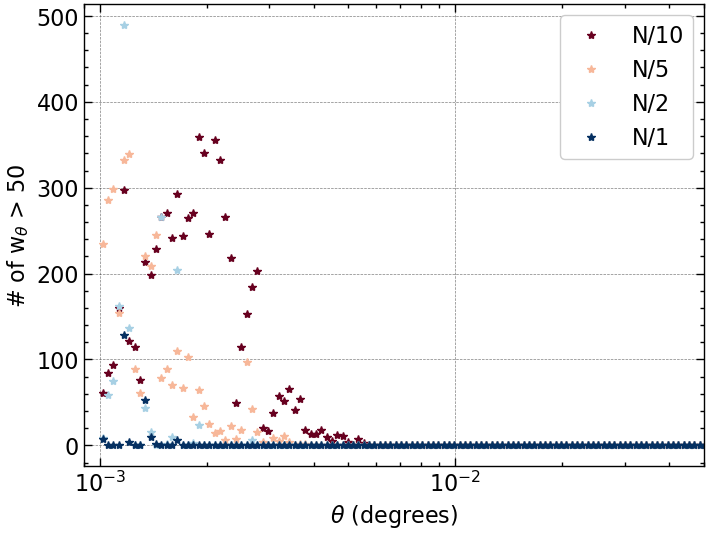

In [23]:
colors = plt.cm.RdBu(np.linspace(0, 1, 4))
plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by10[:,i]>50) for i in range(w_theta_north_by10.shape[1])],'*',color=colors[0],label='N/10')

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by5[:,i]>50) for i in range(w_theta_north_by5.shape[1])],'*',color=colors[1],label='N/5')
plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by2[:,i]>50) for i in range(w_theta_north_by2.shape[1])],'*',color=colors[2],label='N/2')

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by1[:,i]>50) for i in range(w_theta_north_by1.shape[1])],'*',color=colors[3],label='N/1')

plt.xscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'# of w$_\theta$ > 50')
plt.legend()
plt.xlim(9e-4,5e-2)

In [5]:
import pyccl as ccl

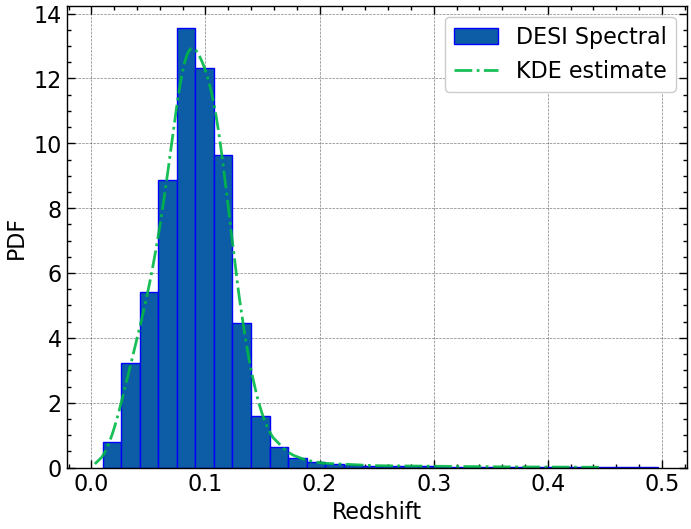

In [53]:
cosmo_params = dict(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965,       # Spectral index,
    transfer_function="boltzmann_camb"
)


from scipy.stats import gaussian_kde
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(500).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

plt.hist(matched_dr['Z'],bins=30,edgecolor='blue',label='DESI Spectral',density=True)

plt.plot(samples_sorted,y_samples_sorted,'-.',alpha=0.9,label='KDE estimate')
plt.xlabel('Redshift')
plt.ylabel('PDF')
plt.legend()
z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)
# linear galaxy bias
bias = 1*np.ones_like(z) #+ 0.5*z

theta = np.logspace(np.log10(1/60), np.log10(3), 40) # degrees
ell = np.arange(2, 4000)
cosmo_lin = ccl.Cosmology(
    **cosmo_params,
    matter_power_spectrum="linear"
)
tr_lin = ccl.NumberCountsTracer(cosmo_lin, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
cl_lin = ccl.angular_cl(cosmo_lin, tr_lin, tr_lin, ell)
wtheta_lin = ccl.correlation(theta = theta, ell = ell, C_ell = cl_lin, cosmo = cosmo_lin)
cosmo_hm = ccl.Cosmology(
    **cosmo_params,
    matter_power_spectrum="camb",
    baryonic_effects=None,
    
    extra_parameters={
        "camb": {
            "halofit_version": "mead2020",
            # "HMCode_A_baryon": 3.13,
            # "HMCode_eta_baryon": 0.603,
            # "HMCode_logT_AGN": 7.8
        }
    }

)

tr_hm = ccl.NumberCountsTracer(cosmo_hm, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
cl_hm = ccl.angular_cl(cosmo_hm, tr_hm, tr_hm, ell)
wtheta_hm = ccl.correlation(theta = theta, ell = ell, C_ell = cl_hm, cosmo = cosmo_hm)


cosmo_hm2 = ccl.Cosmology(
    **cosmo_params,
    matter_power_spectrum="camb",
    baryonic_effects=None,
    
    extra_parameters={
        "camb": {
            "halofit_version": "mead2020_feedback",
            # "HMCode_A_baryon": 3.13,
            # "HMCode_eta_baryon": 0.603,
            # "HMCode_logT_AGN": 7.8
        }
    }

)

tr_hm2 = ccl.NumberCountsTracer(cosmo_hm2, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
cl_hm2 = ccl.angular_cl(cosmo_hm2, tr_hm2, tr_hm2, ell)
wtheta_hm2 = ccl.correlation(theta = theta, ell = ell, C_ell = cl_hm2, cosmo = cosmo_hm2)

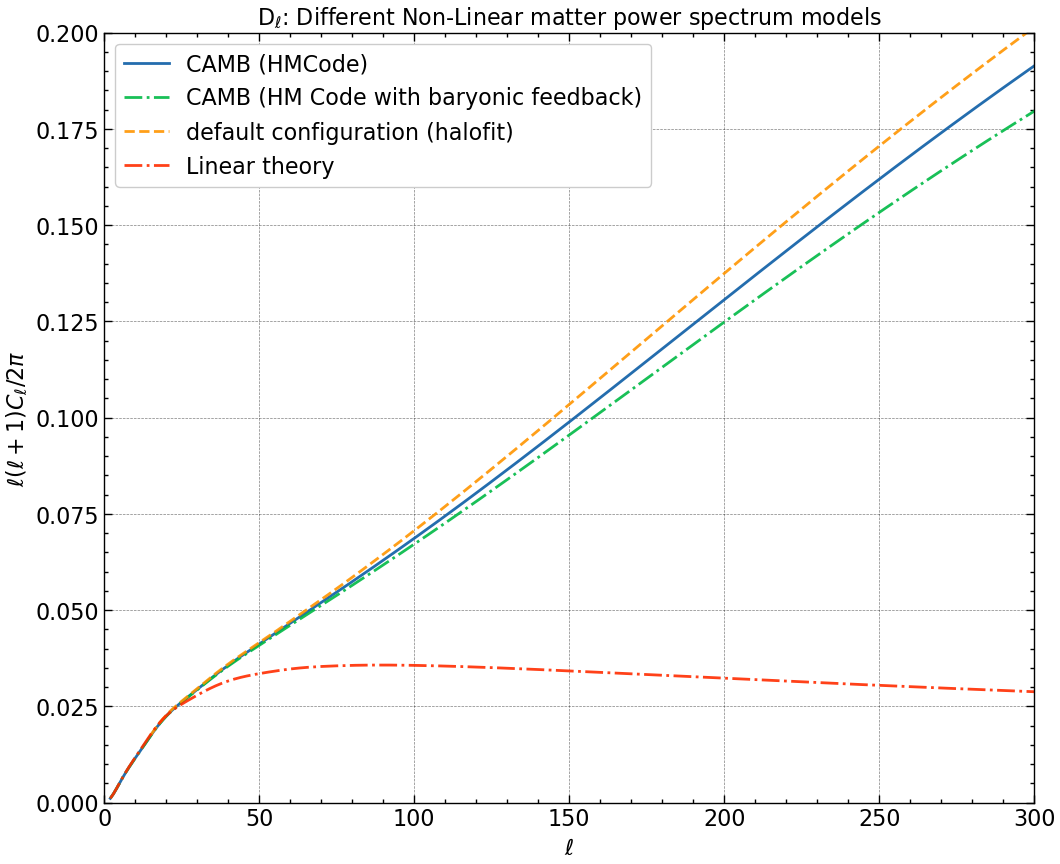

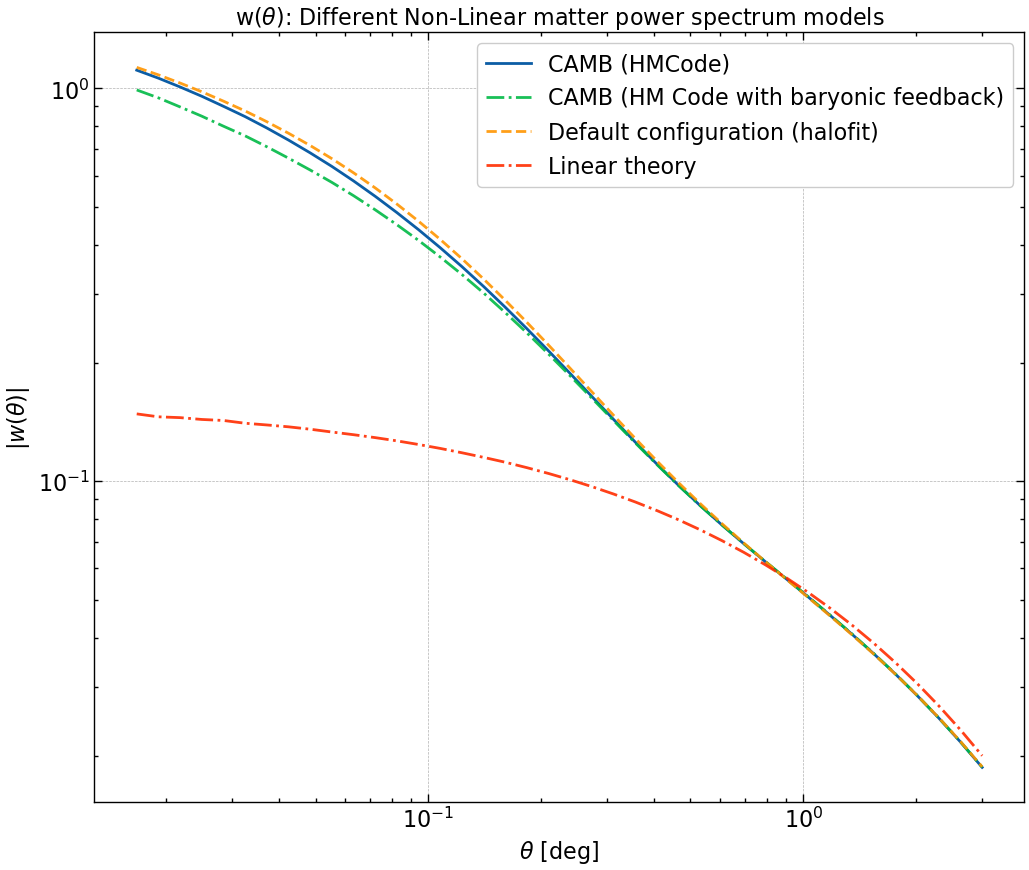

In [61]:

plt.figure(figsize=(12,10))

z=samples_sorted
n_z = y_samples_sorted
gal_tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
ell1 = np.arange(15, 400)

def dll(a,ell):
    cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
    dl=ell*(ell+1)*cls_gg/2/np.pi
    return a*dl 

def w_theta_default(ell):
    cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)

    return ccl.correlation(theta = theta, ell = ell, C_ell = cls_gg, cosmo = cosmo)

plt.plot(ell, ell*(ell+1)*cl_hm/2/np.pi, label="CAMB (HMCode)",alpha=0.9)
plt.plot(ell, ell*(ell+1)*cl_hm2/2/np.pi, label="CAMB (HM Code with baryonic feedback)",alpha=0.9,ls= '-.')

plt.plot(ell1,dll(1,ell1),label = 'default configuration (halofit)',alpha=0.9,ls='--')

plt.plot(ell, ell*(ell+1)*cl_lin/2/np.pi, label="Linear theory",alpha =0.9,ls ='-.')
plt.title("D$_\ell$: Different Non-Linear matter power spectrum models")
plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$")
plt.xlabel(r"$\ell$")
plt.legend()
plt.xlim(0,300)
plt.ylim(0,0.20)


plt.figure(figsize=(12,10))
plt.loglog(theta, np.abs(wtheta_hm), label="CAMB (HMCode)")
plt.loglog(theta, np.abs(wtheta_hm2), label="CAMB (HM Code with baryonic feedback)",ls='-.',alpha=0.9)
plt.loglog(theta, np.abs(w_theta_default(ell)), label="Default configuration (halofit)",ls='--',alpha=0.9)
plt.loglog(theta, np.abs(wtheta_lin), label="Linear theory",ls='-.',alpha=0.9)
plt.title(r"w($\theta$): Different Non-Linear matter power spectrum models")

plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$|w(\theta)|$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [ ]:
8591269166

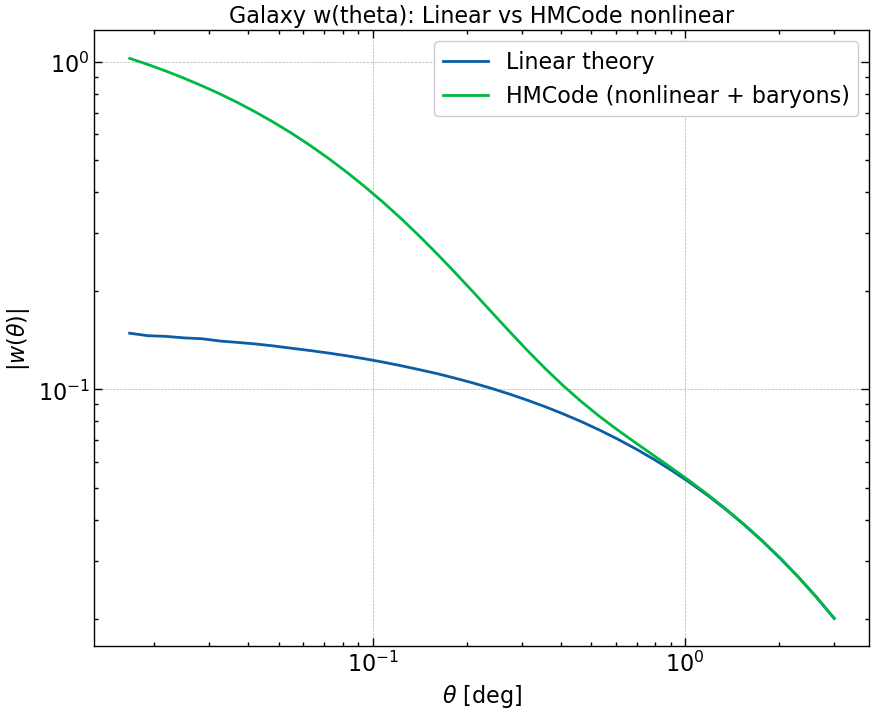

In [34]:
plt.figure(figsize=(10,8))

plt.loglog(theta, np.abs(wtheta_lin), label="Linear theory")
plt.loglog(theta, np.abs(wtheta_hm), label="HMCode (nonlinear + baryons)")


plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$|w(\theta)|$")
plt.title("Galaxy w(theta): Linear vs HMCode nonlinear")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

(0.0, 300.0)

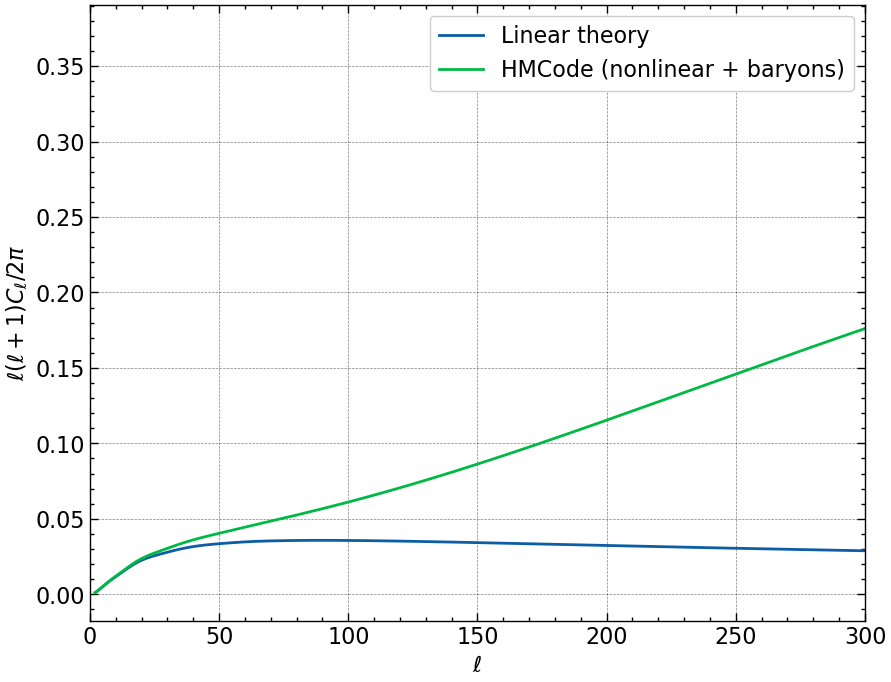

In [35]:
plt.figure(figsize=(10,8))
plt.plot(ell, ell*(ell+1)*cl_lin/2/np.pi, label="Linear theory")
plt.plot(ell, ell*(ell+1)*cl_hm/2/np.pi, label="HMCode (nonlinear + baryons)")
plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$")
plt.xlabel(r"$\ell$")
plt.legend()
plt.xlim(0,300)
#plt.ylim(0,0.06)


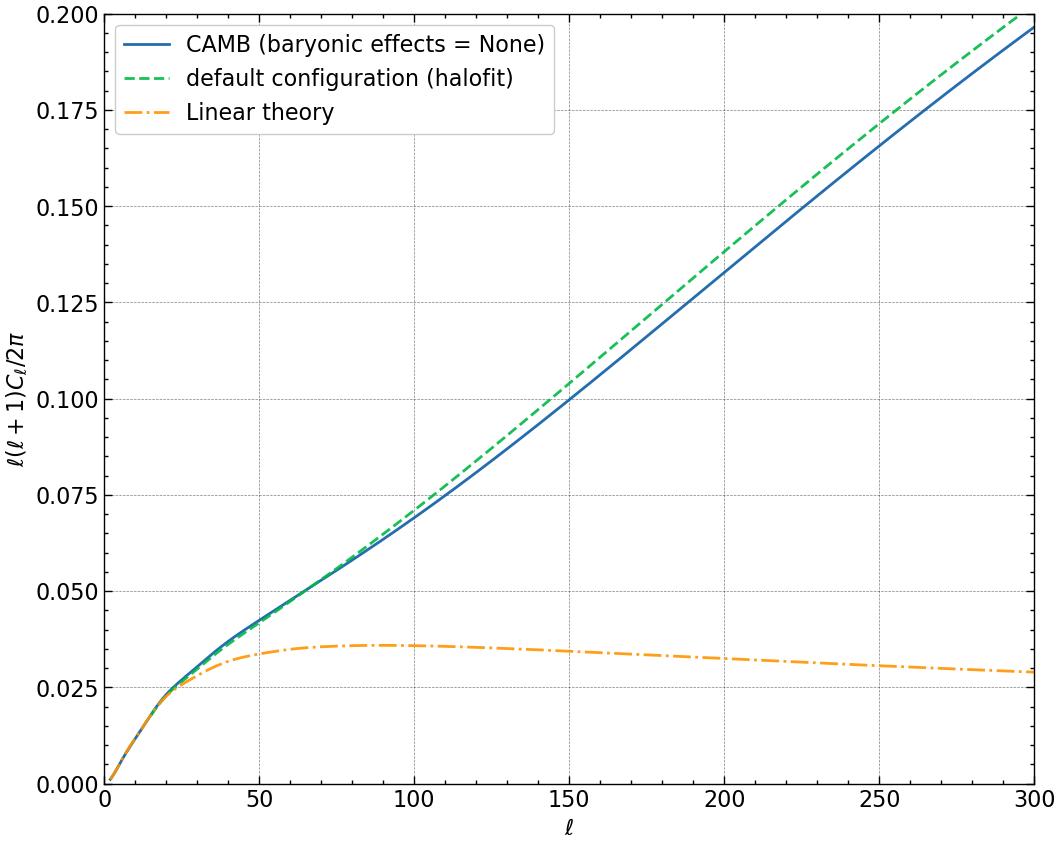

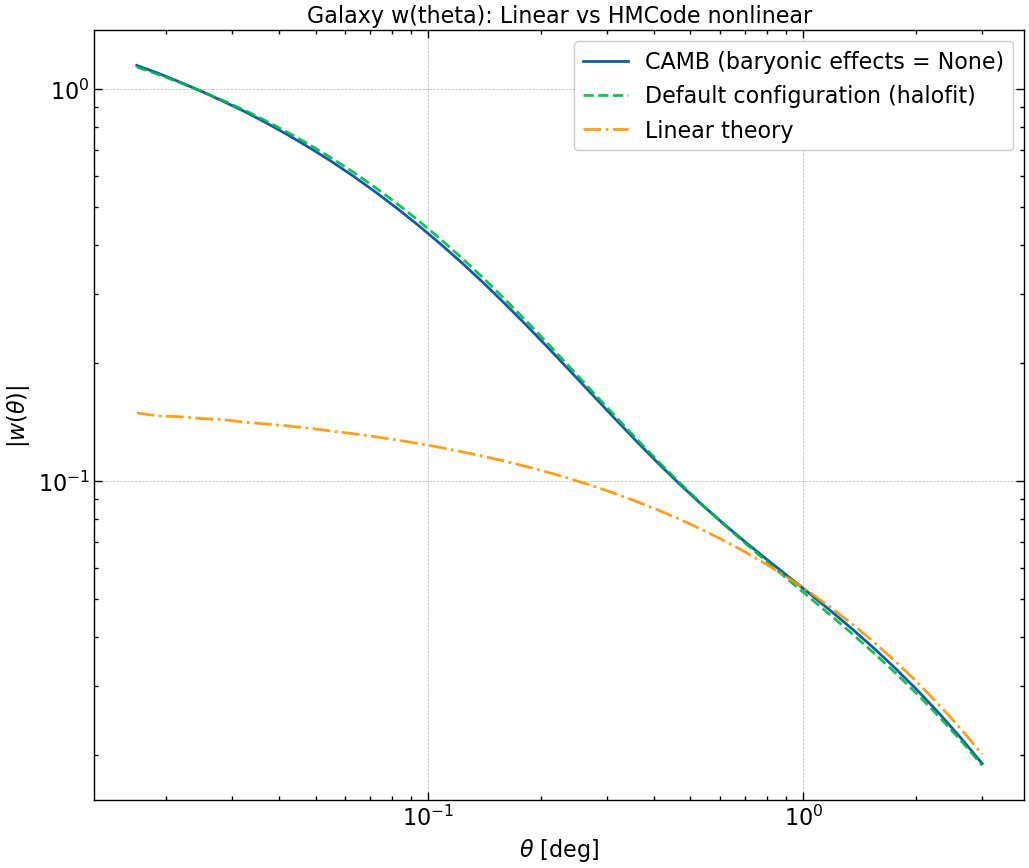

In [40]:
cosmo = ccl.Cosmology(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965       # Spectral index
    
)
plt.figure(figsize=(12,10))

z=samples_sorted
n_z = y_samples_sorted
gal_tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
ell1 = np.arange(15, 400)

def dll(a,ell):
    cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
    dl=ell*(ell+1)*cls_gg/2/np.pi
    return a*dl 

def w_theta_default(ell):
    cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)

    return ccl.correlation(theta = theta, ell = ell, C_ell = cls_gg, cosmo = cosmo)

plt.plot(ell, ell*(ell+1)*cl_hm/2/np.pi, label="CAMB (baryonic effects = None)",alpha=0.9)
plt.plot(ell1,dll(1,ell1),label = 'default configuration (halofit)',alpha=0.9,ls='--')

plt.plot(ell, ell*(ell+1)*cl_lin/2/np.pi, label="Linear theory",alpha =0.9,ls ='-.')

plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$")
plt.xlabel(r"$\ell$")
plt.legend()
plt.xlim(0,300)
plt.ylim(0,0.20)


plt.figure(figsize=(12,10))
plt.loglog(theta, np.abs(wtheta_hm), label="CAMB (baryonic effects = None)")
plt.loglog(theta, np.abs(w_theta_default(ell)), label="Default configuration (halofit)",ls='--',alpha=0.9)
plt.loglog(theta, np.abs(wtheta_lin), label="Linear theory",ls='-.',alpha=0.9)


plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$|w(\theta)|$")
plt.title("Galaxy w(theta): Linear vs HMCode nonlinear")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl

# ---------- Common setup ----------
cosmo_params = dict(
    Omega_c=0.25, Omega_b=0.05, h=0.67,
    sigma8=0.81, n_s=0.965,
    transfer_function="boltzmann_camb"
)

z = np.linspace(0, 2, 300)
nz = np.exp(-0.5*((z-0.8)/0.3)**2); nz /= np.trapz(nz, z)
bz = 1.5 + 0.5*z

# 1 arcmin to 3 deg, in DEGREES
theta = np.logspace(np.log10(1/60), np.log10(3), 50)
# Go high in ell for small-angle behaviour
ell = np.arange(2, 20000)

def cosine_taper(x, x0, x1):
    f = np.ones_like(x, dtype=float)
    m = (x>=x0) & (x<=x1)
    f[x>x1] = 0.0
    f[m] = 0.5*(1 + np.cos(np.pi*(x[m] - x0)/(x1 - x0)))
    return f

tap = cosine_taper(ell, 12000, 18000)

# ---------- Linear ----------
cosmo_lin = ccl.Cosmology(**cosmo_params, matter_power_spectrum="linear")
tr = ccl.NumberCountsTracer(cosmo_lin, dndz=(z, nz), bias=(z, bz), has_rsd=False)
cl_lin = ccl.angular_cl(cosmo_lin, tr, tr, ell)

# ---------- HMCode nonlinear ----------
cosmo_hm = ccl.Cosmology(
    **cosmo_params,
    matter_power_spectrum="halofit",  # yes, the name is misleading
    extra_parameters={"camb": {
        "halofit_version": "mead2020_feedback",  # HMCode2020 feedback
        "HMCode_logT_AGN": 7.8                   # baryon strength
    }}
)
tr_hm = ccl.NumberCountsTracer(cosmo_hm, dndz=(z, nz), bias=(z, bz), has_rsd=False)
cl_hm = ccl.angular_cl(cosmo_hm, tr_hm, tr_hm, ell)

# ---------- Sanity: P(k) suppression at high k ----------
k = np.logspace(-2, 1.3, 200)  # 0.01..20 h/Mpc
pk_lin = ccl.linear_matter_power(cosmo_lin, k, 0.5)
pk_hm  = ccl.nonlin_matter_power(cosmo_hm,  k, 0.5)

# ---------- Sanity: C_ell suppression ----------
# Optional shot noise (per steradian), comment both or keep both
# nbar = 3e8
# cl_lin = cl_lin + 1/nbar; cl_hm = cl_hm + 1/nbar

# Taper to reduce ringing in the θ transform
cl_lin_t = cl_lin * tap
cl_hm_t  = cl_hm  * tap

# ---------- w(theta) in configuration space (signed, not abs) ----------
w_lin = ccl.correlation(theta=theta, ell=ell, C_ell=cl_lin_t, cosmo=cosmo_lin)
w_hm  = ccl.correlation(theta=theta, ell=ell, C_ell=cl_hm_t,  cosmo=cosmo_hm)

# ---------- Plots ----------
plt.figure(figsize=(6.5,4.5))
plt.loglog(theta, np.maximum(w_lin, 1e-20), label='Linear')
plt.loglog(theta, np.maximum(w_hm,  1e-20), label='HMCode')
plt.xlabel(r'$\theta$ [deg]'); plt.ylabel(r'$w(\theta)$')
plt.title('w(θ): Linear vs HMCode'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6.5,3.8))
ratio = w_hm / w_lin
plt.semilogx(theta, ratio)
plt.axhline(1, ls='--', lw=1, color='k')
plt.xlabel(r'$\theta$ [deg]'); plt.ylabel('HMCode / Linear')
plt.title('Suppression from HMCode'); plt.grid(alpha=0.3)
plt.show()

# Optional checks if you want to eyeball the ingredients:
plt.figure(figsize=(6.5,4.5))
plt.loglog(k, pk_lin, label='P_lin(z=0.5)')
plt.loglog(k, pk_hm, label='P_HMCode(z=0.5)')
plt.xlabel('k [h/Mpc]'); plt.ylabel('P(k)'); plt.legend(); plt.grid(alpha=0.3); plt.show()

plt.figure(figsize=(6.5,4.5))
plt.loglog(ell, cl_lin, label='C_ell linear')
plt.loglog(ell, cl_hm,  label='C_ell HMCode')
plt.xlabel('ℓ'); plt.ylabel(r'$C_\ell$'); plt.legend(); plt.grid(alpha=0.3); plt.show()


CCLError: Error CCL_ERROR_SPLINE: ccl_correlation.c: ccl_tracer_corr_fftlog(): failed to create spline


In [71]:
w_lin = ccl.correlation(cosmo_lin, ell, cl_lin_t, theta, "GG")
w_hm  = ccl.correlation(cosmo_hm, ell, cl_hm_t, theta, "GG")



TypeError: correlation() takes 1 positional argument but 5 were given

In [72]:
w_lin = ccl.correlation(cosmo_lin, ell, cl_lin_t, theta, type='NN')
w_hm  = ccl.correlation(cosmo_hm,  ell, cl_hm_t,  theta, type='NN')


TypeError: correlation() takes 1 positional argument but 4 positional arguments (and 1 keyword-only argument) were given